# Littora: EDA полевых наблюдений и готовность к обучению

**Задача:** определить, какие метки действительно есть, проверить их качество и независимость,
посчитать воспроизводимые базовые метрики и выбрать следующий эксперимент.
Основание: `docs/descriptions/Постановка_Макропластик_КосмоХакатон.pdf` (стр. 2–5),
`Критерии_Макропластик_КосмоХакатон.pdf` (О1–О3, Т1–Т4), README набора.

Различаем три уровня доказательств: полевые плотности, разметка спутниковых изображений,
синхронные пары с полевыми измерениями. Один уровень не заменяет другой.
Весь анализ выполняется локально; сеть и повторный запрос STAC не требуются.
Реестры пар проверяются как сохранённый снимок результатов, исходные данные не изменяются.
Числа в таблицах и заключении вычисляются при запуске, графики и метрики сохраняются в `reports/eda/`.

Порядок: инвентаризация → контракт → отбор → измерения → распределения → география/время →
спутниковые пары → признаки и зависимости → grouped CV → ошибки/неопределённость → план обучения.

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import json
import platform
import sys
import tomllib
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from pypdf import PdfReader
from pyproj import Geod
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics.pairwise import haversine_distances
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/case/macroplastic_marine_samples.csv").exists())
OUT = ROOT / "reports/eda"
for p in (OUT, OUT / "tables", OUT / "figures"):
    p.mkdir(parents=True, exist_ok=True)
CFG = tomllib.loads((ROOT / "ml/eda/config.toml").read_text())
CASE_CFG = tomllib.loads((ROOT / "backend/config/case.toml").read_text())
Y = "concentration_items_km2"
PROFILE = "measurement_profile"
sns.set_theme(style="whitegrid", font="DejaVu Sans", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150})
pd.set_option("display.max_columns", 16)
pd.set_option("display.max_rows", 65)
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
TABLES = {}

def table(name, frame, show=True):
    TABLES[name] = frame.copy()
    frame.to_csv(OUT / "tables" / f"{name}.csv", index=False)
    if show:
        display(frame)
    return frame

def figure(name):
    plt.tight_layout()
    plt.savefig(OUT / "figures" / f"{name}.png", bbox_inches="tight")
    plt.show()
    plt.close()

def sha(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

raw = pd.read_csv(ROOT / "data/case/macroplastic_marine_samples.csv", keep_default_na=False, dtype=str)
df = raw.replace("", np.nan).copy()
numeric = ["latitude", "longitude", "lat_start", "lon_start", "lat_end", "lon_end", "items_count",
           "concentration_value_orig", Y, "concentration_g_km2", "transect_length_km", "transect_width_m",
           "sampled_area_km2", "sea_state_beaufort", "wind_speed_kn", "reported_concentration_items_km2",
           "reported_concentration_g_km2", "parent_concentration_items_km2", "density_numerator_items",
           "source_reported_total_items", "source_object_filtered_items"]
parse_errors = {}
for c in numeric:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    parse_errors[c] = int(((raw[c] != "") & df[c].isna()).sum())
df["date"] = pd.to_datetime(df.date_utc, errors="coerce", utc=True)
obs = pd.read_csv(ROOT / "reports/registry/observations.csv")
pairs = pd.read_csv(ROOT / "reports/registry/pairs.csv")
event_geo = json.loads((ROOT / "reports/registry/events.geojson").read_text())
events = pd.DataFrame([f["properties"] for f in event_geo["features"]])
registry_summary = json.loads((ROOT / "reports/registry/summary.json").read_text())
inputs = [ROOT / "data/case/macroplastic_marine_samples.csv", ROOT / "data/case/README_macroplastic_dataset.md",
          ROOT / "backend/config/case.toml", ROOT / "data/sources.toml", ROOT / "ml/eda/config.toml",
          ROOT / "ml/eda/macroplastic_eda.py", ROOT / "ml/eda/run.py", ROOT / "ml/eda/requirements.lock.txt",
          *sorted((ROOT / "docs/descriptions").glob("*.pdf")),
          *sorted((ROOT / "reports/registry").glob("*")), *sorted((ROOT / "data/manifests").glob("*.json"))]
provenance = table("input_hashes", pd.DataFrame([{"path": str(p.relative_to(ROOT)), "bytes": p.stat().st_size,
                                              "sha256": sha(p)} for p in inputs]), show=False)
versions = {name: importlib.metadata.version(name) for name in
            ["pandas", "numpy", "matplotlib", "seaborn", "scipy", "scikit-learn", "nbclient", "pypdf", "pyproj"]}
run_info = {"executed_at_utc": datetime.now(timezone.utc).isoformat(), "python": sys.version,
            "platform": platform.platform(), "versions": versions, "config": CFG, "network_required": False}
(OUT / "run_info.json").write_text(json.dumps(run_info, ensure_ascii=False, indent=2))
display(Markdown(f"**Загружено:** {len(df)} строк × {len(raw.columns)} полей; {df.event_id.nunique()} событий. "
                 f"Период: {df.date.min():%Y-%m-%d} — {df.date.max():%Y-%m-%d}."))

**Загружено:** 935 строк × 56 полей; 318 событий. Период: 2014-04-03 — 2024-06-18.

## 1. Требования и реально доступные файлы
Манифест с `retrieved` и числом байт не доказывает, что файлы есть в текущем checkout.
Перечисляем физические файлы отдельно. README и PDF доступны целиком; извлечённый текст
сохраняется для воспроизводимой связи выводов с постановкой.

In [2]:
for p in sorted((ROOT / "docs/descriptions").glob("*.pdf")):
    reader = PdfReader(p)
    text = "\n\n".join(f"PAGE {i + 1}\n{page.extract_text()}" for i, page in enumerate(reader.pages))
    (OUT / (p.stem + ".txt")).write_text(text)
catalog = tomllib.loads((ROOT / "data/sources.toml").read_text())
inventory_rows = []
for key, spec in catalog.items():
    local = ROOT / "data/external" / key
    files = [p for p in local.rglob("*") if p.is_file()] if local.exists() else []
    manifest_path = ROOT / "data/manifests" / f"{key}.json"
    manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
    inventory_rows.append(dict(source=key, kind=spec.get("kind"), license=spec.get("license"),
                               manifest_exists=manifest_path.exists(), manifest_bytes=manifest.get("bytes"),
                               local_files=len(files), local_bytes=sum(p.stat().st_size for p in files),
                               intended_use=",".join(spec.get("use", []))))
inventory = table("source_inventory", pd.DataFrame(inventory_rows))
physical = [p for p in (ROOT / "data").rglob("*") if p.is_file() and p.name != ".gitkeep"]
table("physical_files", pd.DataFrame([{"path": str(p.relative_to(ROOT)), "bytes": p.stat().st_size}
                                     for p in physical]), show=False)
raster_files = [p for p in physical if p.suffix.lower() in {".tif", ".tiff", ".jp2", ".nc", ".h5"}]
display(Markdown(f"Локальных растров: **{len(raster_files)}**. Precision/recall/F1/IoU детектора "
                 "не вычисляются без исходных изображений, эталонных масок и предсказаний. "
                 "Полевой ноль не является пиксельной меткой чистой воды."))

,source,kind,license,manifest_exists,manifest_bytes,local_files,local_bytes,intended_use
0,marida,labelled,CC-BY-4.0,True,1.165e+09,0,0,"pretrain,validation"
1,marida-juliaeo,labelled,CC-BY-4.0,True,9.562e+07,0,0,"baseline,validation"
2,mados,labelled,CC-BY-4.0,True,4.038e+09,0,0,"pretrain,validation"
3,plp2019,labelled,CC-BY-4.0,True,6.889e+07,0,0,"calibration,validation"
4,plp2021,labelled,CC-BY-4.0,True,7.387e+09,0,0,"calibration,validation"
5,plp2022-2023,labelled,CC-BY-4.0,True,3.829e+09,0,0,"calibration,validation"
6,windrows-med,labelled,CC-BY-4.0,True,2.065e+09,0,0,"pretrain,validation"
7,marinedebrisdetector,labelled,как у исходных,True,1.233e+09,0,0,"pretrain,validation"
8,nasa-marine-debris,labelled,CC-BY-NC-4.0,True,7.721e+07,0,0,validation
9,litterlines,labelled,CC-BY-4.0,True,3.823e+05,0,0,validation


Локальных растров: **0**. Precision/recall/F1/IoU детектора не вычисляются без исходных изображений, эталонных масок и предсказаний. Полевой ноль не является пиксельной меткой чистой воды.

## 2. Контракт, пропуски, ключи и связи
Пропуск означает неизвестно/неприменимо. Анализ пропусков делается по источнику и типу записи:
отсутствие плотности у отдельного предмета предусмотрено контрактом.
Проверка `sample_id` и `parent_sample_id` не заменяет проверку независимости событий.

,check,value
0,rows,935
1,columns,56
2,events,318
3,duplicate_sample_ids,0
4,duplicate_full_rows,0
5,duplicate_rows_without_sample_id,3
6,missing_sample_or_event_id,0
7,numeric_parse_errors,0
8,nonfinite_numeric_values,0
9,invalid_or_missing_dates,0


,sample_id,event_id,record_type,litter_item_type,source_row_refs
97,MPL-0098,S3:HE419_MarLitter_transect20,item_observation,plastic fragment,890782 data row 52
98,MPL-0099,S3:HE419_MarLitter_transect20,item_observation,plastic fragment,890782 data row 52
168,MPL-0169,S3:HE419_MarLitter_transect28,item_observation,plastic fragment,890782 data row 60
169,MPL-0170,S3:HE419_MarLitter_transect28,item_observation,plastic fragment,890782 data row 60
391,MPL-0392,S2:MSM41_litter-T46,item_observation,plastic fragment,Transect meta data!K53;MSM41_litter-T46:Plasti...
392,MPL-0393,S2:MSM41_litter-T46,item_observation,plastic fragment,Transect meta data!K53;MSM41_litter-T46:Plasti...


Совпадение всех полей, кроме sample_id, у объектных строк требует проверки происхождения. Такие записи не удаляются автоматически: одинаковое описание может принадлежать разным предметам. В выбранных event-level целях эти объектные строки не используются.

,field,dtype,missing,missing_pct,unique_nonnull
0,sample_id,str,0,0,935
1,source_id,str,0,0,4
2,source_short,str,0,0,4
3,source_doi,str,0,0,4
4,source_license,str,0,0,2
5,region,str,0,0,4
6,sea_area,str,0,0,4
7,record_type,str,0,0,2
8,sampling_method,str,0,0,8
9,platform,str,0,0,5


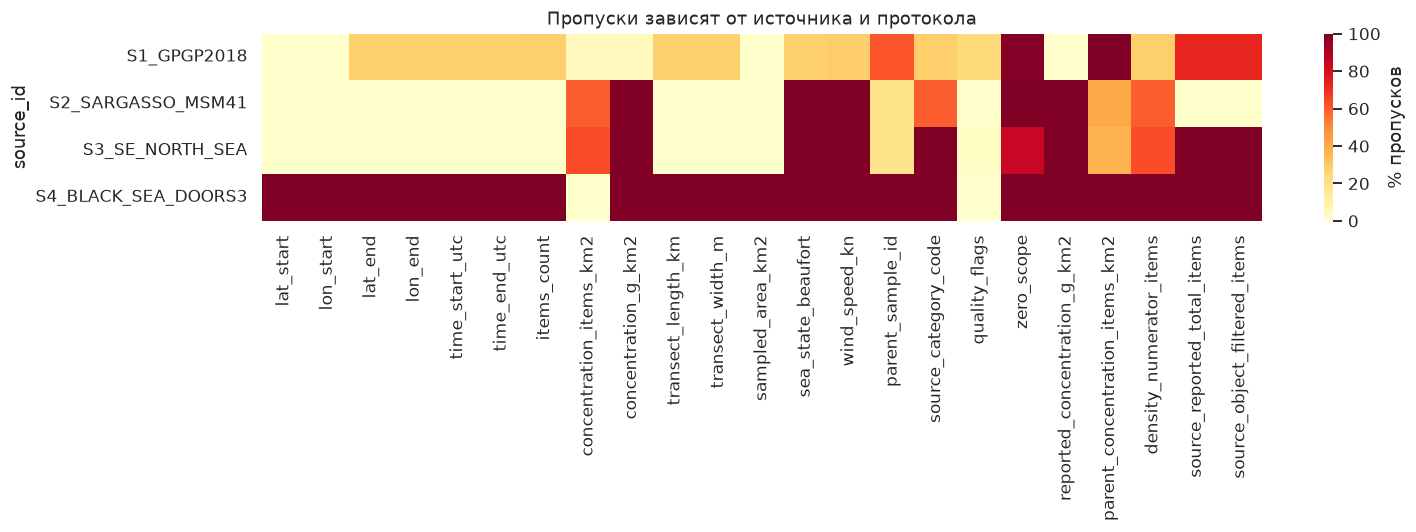

,source_id,rows,events,date_min,date_max,own_density,methods,profiles
0,S1_GPGP2018,350,181,2015-07-25 00:00:00+00:00,2016-10-06 00:00:00+00:00,335,3,5
1,S2_SARGASSO_MSM41,330,63,2015-04-01 00:00:00+00:00,2015-04-26 00:00:00+00:00,133,2,1
2,S3_SE_NORTH_SEA,222,41,2014-04-03 00:00:00+00:00,2016-04-10 00:00:00+00:00,82,2,1
3,S4_BLACK_SEA_DOORS3,33,33,2024-06-02 00:00:00+00:00,2024-06-18 00:00:00+00:00,33,1,1


,source_id,record_type,target_scope,measurement_profile,rows,events,with_y
0,S1_GPGP2018,transect_density,plastic_category,S1_aerial_GT50,81,30,81
1,S1_GPGP2018,transect_density,plastic_category,S1_trawl_GT5_F,6,6,6
2,S1_GPGP2018,transect_density,plastic_category,S1_trawl_GT5_H,70,70,70
3,S1_GPGP2018,transect_density,plastic_category,S1_trawl_GT5_N,94,94,94
4,S1_GPGP2018,transect_density,total_plastic,S1_aerial_GT50,16,16,1
5,S1_GPGP2018,transect_density,total_plastic,S1_trawl_5_to_50,83,83,83
6,S2_SARGASSO_MSM41,item_observation,object_context,S2_visual_GT2,197,60,0
7,S2_SARGASSO_MSM41,transect_density,plastic_category,S2_visual_GT2,70,63,70
8,S2_SARGASSO_MSM41,transect_density,total_plastic,S2_visual_GT2,63,63,63
9,S3_SE_NORTH_SEA,item_observation,object_context,S3_visual_GT2,140,39,0


,source_id,record_type,target_scope,measurement_profile,rows,events,with_y
0,S1_GPGP2018,transect_density,plastic_category,S1_aerial_GT50,81,30,81
1,S1_GPGP2018,transect_density,plastic_category,S1_trawl_GT5_F,6,6,6
2,S1_GPGP2018,transect_density,plastic_category,S1_trawl_GT5_H,70,70,70
3,S1_GPGP2018,transect_density,plastic_category,S1_trawl_GT5_N,94,94,94
4,S1_GPGP2018,transect_density,total_plastic,S1_aerial_GT50,16,16,1
5,S1_GPGP2018,transect_density,total_plastic,S1_trawl_5_to_50,83,83,83
6,S2_SARGASSO_MSM41,item_observation,object_context,S2_visual_GT2,197,60,0
7,S2_SARGASSO_MSM41,transect_density,plastic_category,S2_visual_GT2,70,63,70
8,S2_SARGASSO_MSM41,transect_density,total_plastic,S2_visual_GT2,63,63,63
9,S3_SE_NORTH_SEA,item_observation,object_context,S3_visual_GT2,140,39,0


In [3]:
parent = df.loc[df.parent_sample_id.notna(), ["sample_id", "event_id", "parent_sample_id"]].merge(
    df[["sample_id", "event_id", "record_type"]].rename(columns={"sample_id": "parent_sample_id", "event_id": "parent_event_id"}),
    on="parent_sample_id", how="left", validate="many_to_one", indicator=True)
checks = {
    "rows": len(df), "columns": len(raw.columns), "events": df.event_id.nunique(),
    "duplicate_sample_ids": int(df.sample_id.duplicated().sum()),
    "duplicate_full_rows": int(raw.duplicated().sum()),
    "duplicate_rows_without_sample_id": int(raw.drop(columns="sample_id").duplicated().sum()),
    "missing_sample_or_event_id": int(df[["sample_id", "event_id"]].isna().any(axis=1).sum()),
    "numeric_parse_errors": sum(parse_errors.values()),
    "nonfinite_numeric_values": int(np.isinf(df[numeric].to_numpy(dtype=float)).sum()),
    "invalid_or_missing_dates": int(df.date.isna().sum()),
    "invalid_latitude": int((df.latitude.notna() & ~df.latitude.between(-90, 90)).sum()),
    "invalid_longitude": int((df.longitude.notna() & ~df.longitude.between(-180, 180)).sum()),
    "missing_center_coordinates": int(df[["latitude", "longitude"]].isna().any(axis=1).sum()),
    "nonpositive_known_area": int((df.sampled_area_km2.notna() & (df.sampled_area_km2 <= 0)).sum()),
    "negative_concentration": int((df[Y] < 0).sum()),
    "negative_numerator": int((df.density_numerator_items < 0).sum()),
    "orphan_parent_links": int((parent._merge != "both").sum()),
    "cross_event_parent_links": int((parent.event_id != parent.parent_event_id).sum()),
    "self_parent_links": int((parent.sample_id == parent.parent_sample_id).sum()),
    "item_rows_with_own_density": int(((df.record_type == "item_observation") & df[Y].notna()).sum()),
    "zero_without_scope": int(((df[Y] == 0) & df.zero_scope.isna()).sum()),
    "scope_on_nonzero_density": int(((df[Y] != 0) & df[Y].notna() & df.zero_scope.notna()).sum()),
}
audit = table("contract_checks", pd.DataFrame(checks.items(), columns=["check", "value"]))
assert checks["duplicate_sample_ids"] == checks["missing_sample_or_event_id"] == checks["numeric_parse_errors"] == 0
assert checks["orphan_parent_links"] == checks["cross_event_parent_links"] == 0
duplicates = raw.drop(columns="sample_id").duplicated(keep=False)
table("duplicate_content_records", df.loc[duplicates, ["sample_id", "event_id", "record_type", "litter_item_type", "source_row_refs"]])
display(Markdown("Совпадение всех полей, кроме sample_id, у объектных строк требует проверки происхождения. "
                 "Такие записи не удаляются автоматически: одинаковое описание может принадлежать разным предметам. "
                 "В выбранных event-level целях эти объектные строки не используются."))
schema = table("schema_missingness", pd.DataFrame({"field": raw.columns,
    "dtype": [str(df[c].dtype) for c in raw.columns], "missing": [df[c].isna().sum() for c in raw.columns],
    "missing_pct": [100 * df[c].isna().mean() for c in raw.columns],
    "unique_nonnull": [df[c].nunique() for c in raw.columns]}))
missing_source = df.groupby("source_id")[[c for c in raw.columns if c != "source_id"]].agg(lambda s: s.isna().mean() * 100)
table("missingness_by_source", missing_source.reset_index(), show=False)
missing_type = df.groupby("record_type")[[c for c in raw.columns if c != "record_type"]].agg(lambda s: s.isna().mean() * 100)
table("missingness_by_record_type", missing_type.reset_index(), show=False)
varying_missing = schema.loc[schema.missing > 0, "field"]
plt.figure(figsize=(14, 5))
sns.heatmap(missing_source[varying_missing], cmap="YlOrRd", vmin=0, vmax=100, cbar_kws={"label": "% пропусков"})
plt.title("Пропуски зависят от источника и протокола")
figure("01_missingness")
source_summary = table("sources_summary", df.groupby("source_id").agg(
    rows=("sample_id", "size"), events=("event_id", "nunique"), date_min=("date", "min"), date_max=("date", "max"),
    own_density=(Y, "count"), methods=("sampling_method", "nunique"), profiles=(PROFILE, "nunique")).reset_index())
table("record_scope_profile", df.groupby(["source_id", "record_type", "target_scope", PROFILE], dropna=False)
      .agg(rows=("sample_id", "size"), events=("event_id", "nunique"), with_y=(Y, "count")).reset_index())

## 3. Флаги качества и независимый отбор цели
Воспроизводим правила `backend/config/case.toml` на исходном CSV и сравниваем с сохранённым реестром.
Это проверка согласованности, а не автоматическое одобрение всех правил.
`all_litter` остаётся **всем мусором**, а не переименовывается в пластик.
Аэросъёмка и категорийные строки остаются в полном аудите, но не входят в три текущие цели backend.
Профили S3 и S4 оцениваются отдельно, несмотря на общий ключ `litter-visual`.

In [4]:
flags = df[["sample_id", "event_id", "source_id", "quality_flags"]].copy()
flags["flag"] = flags.quality_flags.fillna("").str.split(";")
flags = flags.explode("flag").query("flag != ''")
table("quality_flags", flags.groupby(["source_id", "flag"]).agg(rows=("sample_id", "nunique"), events=("event_id", "nunique")).reset_index())

def select(row):
    rules = CASE_CFG["selection"]
    if row.record_type != rules["record_type"]:
        return "item_observation", None
    if row.target_scope in rules["category_scopes"]:
        return "category", None
    matching = [t for t in CASE_CFG["targets"] if row[PROFILE] in t["profiles"]]
    if not matching:
        return "profile_not_targeted", None
    matching = [t for t in matching if row.target_scope in t["target_scope"]]
    if not matching:
        return "scope_mismatch", None
    target = matching[0]["key"]
    if pd.isna(row[Y]):
        return "no_concentration", target
    if set(str(row.quality_flags).split(";")) & set(rules["exclude_flags"]):
        return "excluded_flag", target
    return "accepted", target

selection = df.apply(select, axis=1)
df["selection_reason"] = [x[0] for x in selection]
df["target_key"] = [x[1] for x in selection]
compare = df[["sample_id", "event_id", "selection_reason", "target_key", Y]].merge(
    obs[["sample_id", "event_id", "reason_code", "target_key", "published_items_km2"]], on="sample_id",
    suffixes=("", "_registry"), how="outer", validate="one_to_one", indicator=True)
compare["consistent"] = ((compare._merge == "both") & (compare.selection_reason == compare.reason_code)
    & (compare.event_id == compare.event_id_registry)
    & (compare.target_key.fillna("") == compare.target_key_registry.fillna(""))
    & np.isclose(compare[Y], compare.published_items_km2, equal_nan=True, rtol=1e-4, atol=1e-4))
table("selection_registry_comparison", compare, show=False)
assert compare.consistent.all(), "Исходные данные/конфигурация расходятся с сохранённым реестром"
selected = df.loc[df.selection_reason == "accepted"].copy().reset_index(drop=True)
assert selected.event_id.is_unique
table("selection_flow", df.groupby("selection_reason").agg(rows=("sample_id", "size"), events=("event_id", "nunique")).reset_index())
target_counts = table("target_counts", selected.groupby(["target_key", PROFILE, "target_scope"]).agg(
    rows=("sample_id", "size"), events=("event_id", "nunique"), zeros=(Y, lambda x: int((x == 0).sum()))).reset_index())
table("excluded_profiles", df.loc[df.selection_reason == "profile_not_targeted"].groupby([PROFILE, "target_scope"])
      .agg(rows=("sample_id", "size"), available_y=(Y, "count"), events=("event_id", "nunique")).reset_index())
flag_sensitivity = []
for flag in ["source_total_vs_object_count_conflict", "source_not_revalidated_in_repair", "numerator_area_unavailable", "all_litter_not_plastic"]:
    for profile, g in selected.groupby(PROFILE):
        removed = g.quality_flags.fillna("").str.split(";").apply(lambda x: flag in x)
        flag_sensitivity.append({"excluded_flag": flag, PROFILE: profile, "before": len(g), "after": int((~removed).sum())})
table("flag_exclusion_sensitivity", pd.DataFrame(flag_sensitivity))

,source_id,flag,rows,events
0,S1_GPGP2018,category_dictionary_corrected,76,72
1,S1_GPGP2018,size_filter_corrected,29,18
2,S1_GPGP2018,source_total_vs_object_count_conflict,94,29
3,S1_GPGP2018,start_coordinate_corrected_to_midpoint,170,150
4,S1_GPGP2018,zero_only_for_defined_scope,3,3
5,S2_SARGASSO_MSM41,author_area_replaces_endpoint_distance,330,63
6,S2_SARGASSO_MSM41,companion_count_differs_sum_float_items,51,7
7,S2_SARGASSO_MSM41,interrupted_transect_summary_area,23,4
8,S2_SARGASSO_MSM41,object_row_match_ambiguous_or_unresolved,29,19
9,S2_SARGASSO_MSM41,object_time_is_parent_interval,197,60


,selection_reason,rows,events
0,accepted,220,220
1,category,362,284
2,item_observation,337,99
3,profile_not_targeted,16,16


,target_key,measurement_profile,target_scope,rows,events,zeros
0,litter-visual,S3_visual_GT2,all_litter,41,41,0
1,litter-visual,S4_visual_GT2_5,all_litter,33,33,0
2,plastic-trawl,S1_trawl_5_to_50,total_plastic,83,83,0
3,plastic-visual,S2_visual_GT2,total_plastic,63,63,0


,measurement_profile,target_scope,rows,available_y,events
0,S1_aerial_GT50,total_plastic,16,1,16


,excluded_flag,measurement_profile,before,after
0,source_total_vs_object_count_conflict,S1_trawl_5_to_50,83,83
1,source_total_vs_object_count_conflict,S2_visual_GT2,63,63
2,source_total_vs_object_count_conflict,S3_visual_GT2,41,41
3,source_total_vs_object_count_conflict,S4_visual_GT2_5,33,33
4,source_not_revalidated_in_repair,S1_trawl_5_to_50,83,83
5,source_not_revalidated_in_repair,S2_visual_GT2,63,63
6,source_not_revalidated_in_repair,S3_visual_GT2,41,41
7,source_not_revalidated_in_repair,S4_visual_GT2_5,33,0
8,numerator_area_unavailable,S1_trawl_5_to_50,83,83
9,numerator_area_unavailable,S2_visual_GT2,63,63


,excluded_flag,measurement_profile,before,after
0,source_total_vs_object_count_conflict,S1_trawl_5_to_50,83,83
1,source_total_vs_object_count_conflict,S2_visual_GT2,63,63
2,source_total_vs_object_count_conflict,S3_visual_GT2,41,41
3,source_total_vs_object_count_conflict,S4_visual_GT2_5,33,33
4,source_not_revalidated_in_repair,S1_trawl_5_to_50,83,83
5,source_not_revalidated_in_repair,S2_visual_GT2,63,63
6,source_not_revalidated_in_repair,S3_visual_GT2,41,41
7,source_not_revalidated_in_repair,S4_visual_GT2_5,33,0
8,numerator_area_unavailable,S1_trawl_5_to_50,83,83
9,numerator_area_unavailable,S2_visual_GT2,63,63


## 4. Числитель, площадь, единицы и нули
Проверяем **density_numerator_items / sampled_area_km2**. `items_count` и подсчёт
объектных строк не подменяют числитель. Published-only не равнозначно ошибке.
Допуски: match ≤0,5%, округление ≤1% из конфигурации. Абсолютную разницу тоже сохраняем.
Площадь `длина × ширина` служит диагностикой: авторская площадь прерванной трансекты имеет приоритет.

In [5]:
density = df.loc[df.record_type == "transect_density"].copy()
density["recomputed"] = density.density_numerator_items / density.sampled_area_km2.where(density.sampled_area_km2 > 0)
density["absolute_difference"] = (density.recomputed - density[Y]).abs()
density["relative_difference"] = density.absolute_difference / density[Y].where(density[Y] != 0)
density.loc[(density[Y] == 0) & (density.recomputed == 0), "relative_difference"] = 0
density["check"] = np.select([
    density[Y].isna(), density.recomputed.isna(),
    density.relative_difference <= CASE_CFG["concentration"]["match_relative"],
    density.relative_difference <= CASE_CFG["concentration"]["rounding_relative"]],
    ["missing", "published_only", "match", "rounding"], default="mismatch")
table("density_audit", density[["sample_id", "event_id", PROFILE, "target_scope", Y, "density_numerator_items",
      "sampled_area_km2", "recomputed", "absolute_difference", "relative_difference", "check", "calculation_method"]], show=False)
table("density_checks_by_profile", density.groupby([PROFILE, "check"]).size().rename("rows").reset_index())
ca = density[["sample_id", "check"]].merge(obs[["sample_id", "concentration_check"]], on="sample_id", validate="one_to_one")
assert (ca.check == ca.concentration_check).all()
assert 12 / 0.20 == 60 and abs(75 - 60) == 15
table("unit_inventory", df.groupby(["concentration_unit_orig", "target_scope", PROFILE], dropna=False).size().rename("rows").reset_index())
table("zero_scopes", density.loc[density[Y] == 0].groupby([PROFILE, "target_scope", "zero_scope"], dropna=False)
      .size().rename("zeros").reset_index())
area = density.drop_duplicates("event_id").copy()
area["length_width_area"] = area.transect_length_km * area.transect_width_m / 1000
area["area_relative_difference"] = (area.length_width_area - area.sampled_area_km2) / area.sampled_area_km2
geod = Geod(ellps="WGS84")
has_ends = area[["lon_start", "lat_start", "lon_end", "lat_end"]].notna().all(axis=1)
area.loc[has_ends, "endpoint_distance_km"] = geod.inv(area.loc[has_ends, "lon_start"].to_numpy(),
    area.loc[has_ends, "lat_start"].to_numpy(), area.loc[has_ends, "lon_end"].to_numpy(),
    area.loc[has_ends, "lat_end"].to_numpy())[2] / 1000
area["endpoint_over_length"] = area.endpoint_distance_km / area.transect_length_km
table("area_geometry_audit", area[["event_id", PROFILE, "sampled_area_km2", "length_width_area", "area_relative_difference",
    "transect_length_km", "endpoint_distance_km", "endpoint_over_length", "quality_flags"]], show=False)
display(area.loc[area.area_relative_difference.abs() > .01,
                 ["event_id", PROFILE, "sampled_area_km2", "length_width_area", "area_relative_difference", "quality_flags"]].head(15))
table("interrupted_transects", area.loc[area.quality_flags.fillna("").str.contains("interrupted_transect"),
      ["event_id", "sampled_area_km2", "endpoint_distance_km", "transect_length_km", "quality_flags"]])

,measurement_profile,check,rows
0,S1_aerial_GT50,match,82
1,S1_aerial_GT50,missing,15
2,S1_trawl_5_to_50,published_only,83
3,S1_trawl_GT5_F,match,6
4,S1_trawl_GT5_H,match,70
5,S1_trawl_GT5_N,match,94
6,S2_visual_GT2,match,133
7,S3_visual_GT2,match,76
8,S3_visual_GT2,rounding,6
9,S4_visual_GT2_5,published_only,33


,concentration_unit_orig,target_scope,measurement_profile,rows
0,items km-2,all_litter,S3_visual_GT2,41
1,items km-2,all_litter,S4_visual_GT2_5,33
2,items km-2,fisheries_litter_category,S3_visual_GT2,41
3,items km-2,object_context,S2_visual_GT2,197
4,items km-2,object_context,S3_visual_GT2,140
5,items km-2,plastic_category,S1_aerial_GT50,81
6,items km-2,plastic_category,S1_trawl_GT5_F,6
7,items km-2,plastic_category,S1_trawl_GT5_H,70
8,items km-2,plastic_category,S1_trawl_GT5_N,94
9,items km-2,total_plastic,S1_aerial_GT50,16


,measurement_profile,target_scope,zero_scope,zeros
0,S1_aerial_GT50,plastic_category,plastic_category;S1_aerial_GT50;Unknown,2
1,S1_aerial_GT50,total_plastic,total_plastic;S1_aerial_GT50;total megaplastic,1
2,S3_visual_GT2,fisheries_litter_category,fisheries_litter_category;S3_visual_GT2;fisher...,35


,event_id,measurement_profile,sampled_area_km2,length_width_area,area_relative_difference,quality_flags
259,S2:MSM41_litter-T18,S2_visual_GT2,0.22,0.2128,-0.03255,author_area_replaces_endpoint_distance;interru...
276,S2:MSM41_litter-T22,S2_visual_GT2,0.24,0.2364,-0.01479,author_area_replaces_endpoint_distance;interru...


,event_id,sampled_area_km2,endpoint_distance_km,transect_length_km,quality_flags
259,S2:MSM41_litter-T18,0.22,19.22,21.28,author_area_replaces_endpoint_distance;interru...
276,S2:MSM41_litter-T22,0.24,25.33,23.64,author_area_replaces_endpoint_distance;interru...
357,S2:MSM41_litter-T35,0.18,19.48,18.04,author_area_replaces_endpoint_distance;interru...
408,S2:MSM41_litter-T49,0.23,23.39,23.17,author_area_replaces_endpoint_distance;interru...


,event_id,sampled_area_km2,endpoint_distance_km,transect_length_km,quality_flags
259,S2:MSM41_litter-T18,0.22,19.22,21.28,author_area_replaces_endpoint_distance;interru...
276,S2:MSM41_litter-T22,0.24,25.33,23.64,author_area_replaces_endpoint_distance;interru...
357,S2:MSM41_litter-T35,0.18,19.48,18.04,author_area_replaces_endpoint_distance;interru...
408,S2:MSM41_litter-T49,0.23,23.39,23.17,author_area_replaces_endpoint_distance;interru...


## 5. Распределения целевой величины и выбросы
Одна строка = одно выбранное событие. Статистики не смешивают несовместимые профили.
Логарифм `log1p(C)` сохраняет нули. Верхний хвост не удаляется автоматически:
высокая концентрация может быть содержательным наблюдением.
Сумма N / сумма A относится только к подмножеству с известными числителем и площадью;
это площадь-взвешенная описательная оценка, не «средняя концентрация моря».

,measurement_profile,n,zeros,zero_pct,min,q25,median,mean,...,p95,max,std,skew,iqr_high_outliers,top10pct_share_of_sum_y,known_area_n,pooled_density_known_area
0,S1_trawl_5_to_50,83,0,0,58.42,346.5,633.7,708.8,...,"1,718","2,209",503,0.9831,2,0.2682,0,NaN
1,S2_visual_GT2,63,0,0,4.34,20.54,36.09,53.32,...,127.8,222.7,43.25,1.488,2,0.297,63,53.87
2,S3_visual_GT2,41,0,0,6.1,16.8,29.5,34.7,...,76.9,195.1,35.29,3.249,4,0.3761,41,33.98
3,S4_visual_GT2_5,33,0,0,48.97,102.4,224.9,290.5,...,737.3,976,232.2,1.33,2,0.321,0,NaN


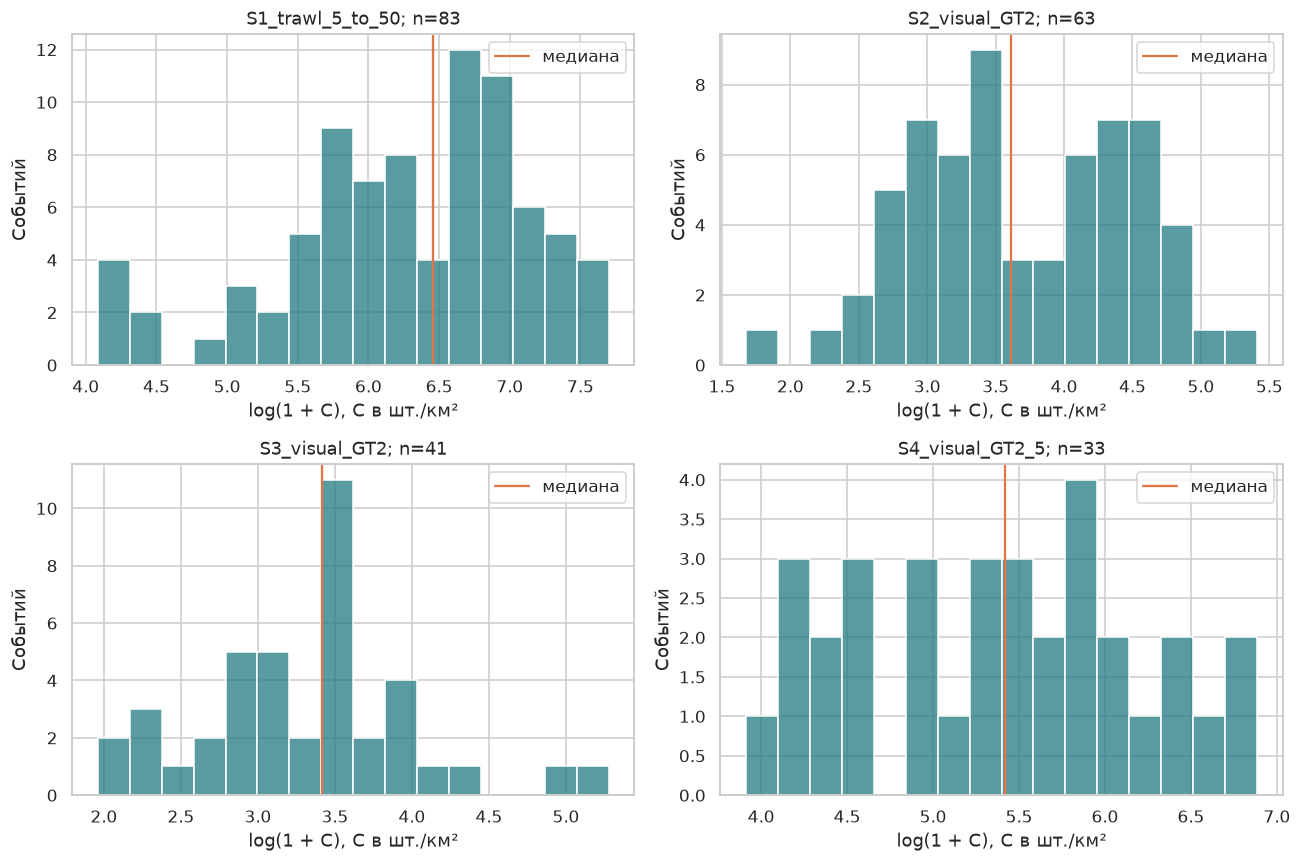

,sample_id,event_id,measurement_profile,concentration_items_km2,density_numerator_items,sampled_area_km2,date_utc,quality_flags
143,MPL-0654,S1:41.3,S1_trawl_5_to_50,"2,209",NaN,0.04617,2015-08-07,NaN
122,MPL-0590,S1:19.4,S1_trawl_5_to_50,"2,109",NaN,0.08012,2015-08-01,NaN
160,MPL-0710,S1:58.4,S1_trawl_5_to_50,"1,849",NaN,0.09518,2015-08-11,NaN
153,MPL-0684,S1:49.3,S1_trawl_5_to_50,"1,820",NaN,0.08077,2015-08-09,NaN
129,MPL-0607,S1:25.3,S1_trawl_5_to_50,"1,719",NaN,0.08491,2015-08-03,NaN
211,MPL-0927,S4:DOORS3:T25,S4_visual_GT2_5,976,NaN,NaN,2024-06-11,all_litter_not_plastic;numerator_area_unavaila...
208,MPL-0924,S4:DOORS3:T22,S4_visual_GT2_5,814.1,NaN,NaN,2024-06-09,all_litter_not_plastic;numerator_area_unavaila...
196,MPL-0912,S4:DOORS3:T3,S4_visual_GT2_5,686.1,NaN,NaN,2024-06-03,all_litter_not_plastic;numerator_area_unavaila...
209,MPL-0925,S4:DOORS3:T24,S4_visual_GT2_5,600.5,NaN,NaN,2024-06-10,all_litter_not_plastic;numerator_area_unavaila...
218,MPL-0934,S4:DOORS3:T30,S4_visual_GT2_5,587.4,NaN,NaN,2024-06-17,all_litter_not_plastic;numerator_area_unavaila...


,measurement_profile,feature,n_pairs,spearman_rho
0,S1_trawl_5_to_50,latitude,83,0.4512
1,S1_trawl_5_to_50,longitude,83,-0.1132
2,S1_trawl_5_to_50,sea_state_beaufort,83,-0.00893
3,S1_trawl_5_to_50,wind_speed_kn,82,0.0624
4,S1_trawl_5_to_50,sampled_area_km2,83,-0.4083
5,S1_trawl_5_to_50,transect_length_km,83,-0.4083
6,S2_visual_GT2,latitude,63,0.3474
7,S2_visual_GT2,longitude,63,0.4013
8,S2_visual_GT2,sea_state_beaufort,0,NaN
9,S2_visual_GT2,wind_speed_kn,0,NaN


Корреляции описательные, без причинной интерпретации. Площадь/длина могут отражать протокол учёта; они не доступны автоматически для спутникового прогноза. Межисточниковая корреляция смешала бы метод, море и год.

In [6]:
stats = []
for profile, g in selected.groupby(PROFILE):
    y = g[Y]
    q1, med, q3 = y.quantile([.25, .5, .75])
    eligible = g.density_numerator_items.notna() & g.sampled_area_km2.gt(0)
    stats.append({PROFILE: profile, "n": len(g), "zeros": int((y == 0).sum()), "zero_pct": 100 * (y == 0).mean(),
        "min": y.min(), "q25": q1, "median": med, "mean": y.mean(), "q75": q3, "p90": y.quantile(.9),
        "p95": y.quantile(.95), "max": y.max(), "std": y.std(), "skew": y.skew(),
        "iqr_high_outliers": int((y > q3 + 1.5 * (q3 - q1)).sum()),
        "top10pct_share_of_sum_y": y.nlargest(max(1, int(np.ceil(len(y) * .1)))).sum() / y.sum(),
        "known_area_n": int(eligible.sum()), "pooled_density_known_area":
        g.loc[eligible, "density_numerator_items"].sum() / g.loc[eligible, "sampled_area_km2"].sum() if eligible.any() else np.nan})
profile_stats = table("profile_statistics", pd.DataFrame(stats))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (profile, g) in zip(axes.flat, selected.groupby(PROFILE)):
    sns.histplot(np.log1p(g[Y]), bins=16, ax=ax, color="#237a83")
    ax.axvline(np.log1p(g[Y].median()), color="#e07646", label="медиана")
    ax.set(title=f"{profile}; n={len(g)}", xlabel="log(1 + C), C в шт./км²", ylabel="Событий")
    ax.legend()
figure("02_target_distributions")
extremes = selected.sort_values(Y, ascending=False).groupby(PROFILE).head(5)
table("high_concentration_events", extremes[["sample_id", "event_id", PROFILE, Y, "density_numerator_items", "sampled_area_km2", "date_utc", "quality_flags"]])
correlations = []
for profile, g in selected.groupby(PROFILE):
    for col in ["latitude", "longitude", "sea_state_beaufort", "wind_speed_kn", "sampled_area_km2", "transect_length_km"]:
        valid = g[[Y, col]].dropna()
        rho = valid[Y].corr(valid[col], method="spearman") if len(valid) >= 5 and valid[col].nunique() > 1 else np.nan
        correlations.append({PROFILE: profile, "feature": col, "n_pairs": len(valid), "spearman_rho": rho})
table("within_profile_correlations", pd.DataFrame(correlations))
display(Markdown("Корреляции описательные, без причинной интерпретации. Площадь/длина могут отражать протокол учёта; "
                 "они не доступны автоматически для спутникового прогноза. Межисточниковая корреляция смешала бы метод, море и год."))

## 6. География, время и повторные наблюдения
Карты ниже — координатные диаграммы без онлайн-подложки. Цвет — log1p концентрации;
шкалы по профилям различаются. Разнесённые экспедиции не образуют непрерывный временной ряд.
Нельзя называть различия S3/S4 временным трендом загрязнения.

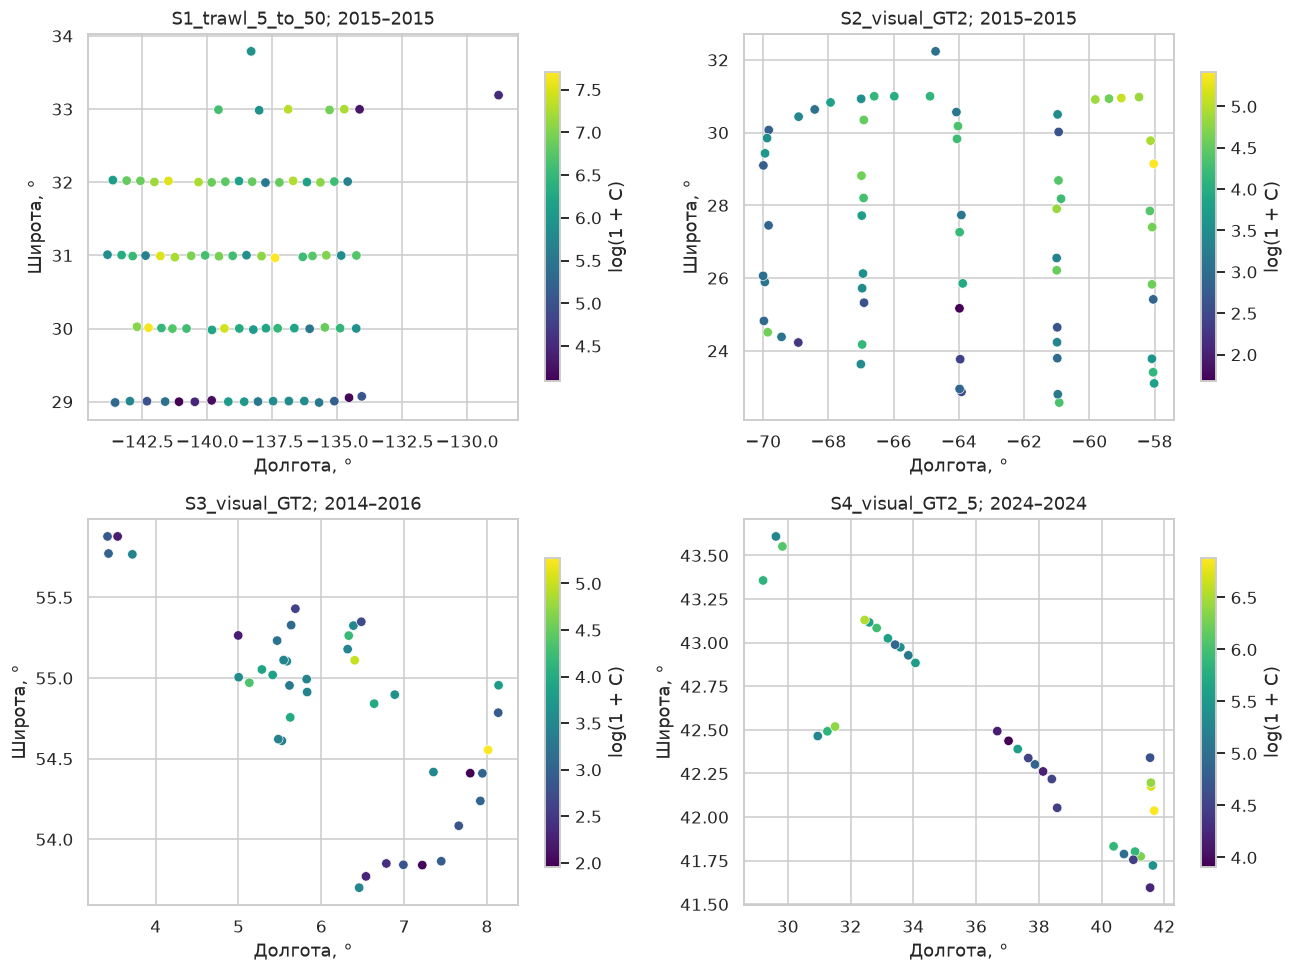

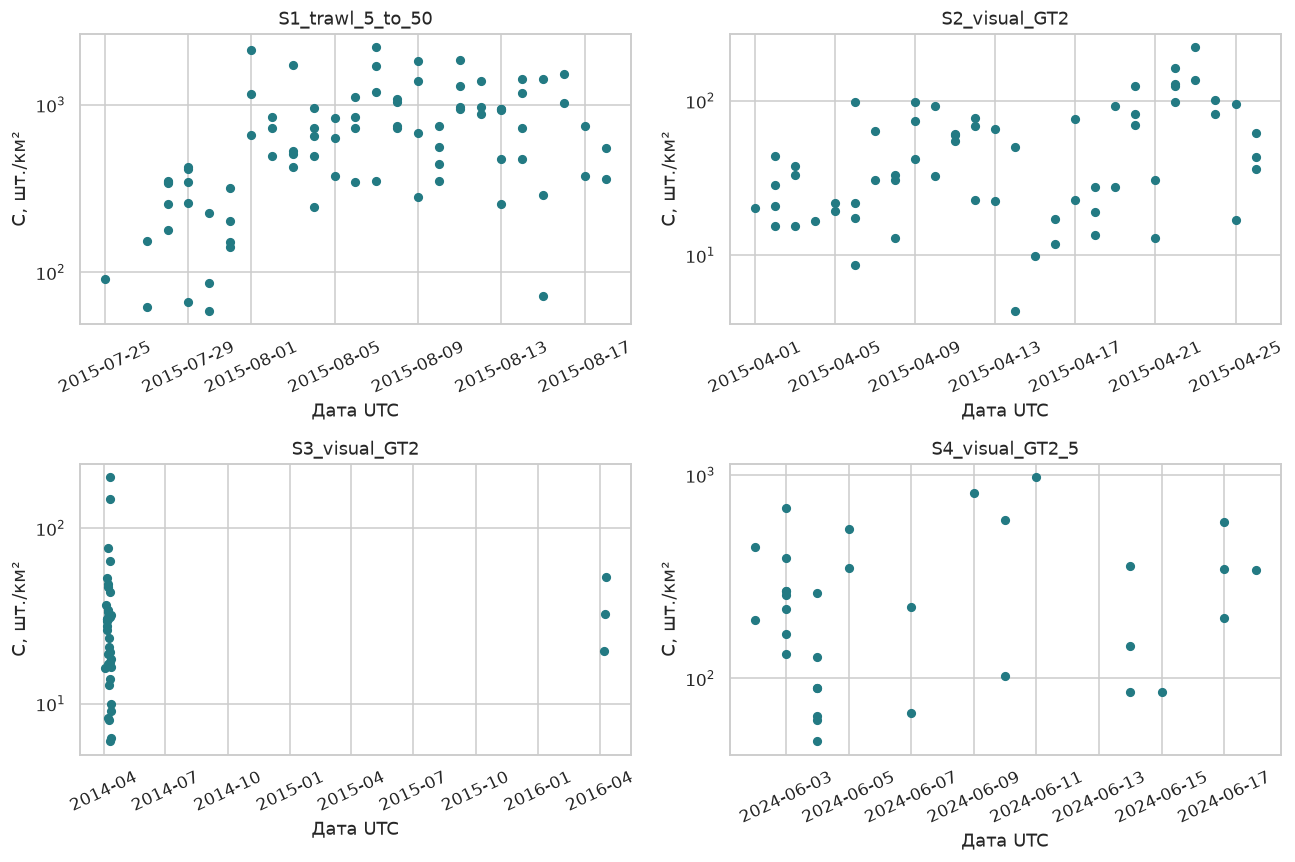

,source_id,events,days,known_start,known_end,cross_midnight,median_duration_hours,max_duration_hours
0,S1_GPGP2018,181,26,150,150,15,3.208,4.017
1,S2_SARGASSO_MSM41,63,26,63,63,0,1,1.85
2,S3_SE_NORTH_SEA,41,12,41,41,0,0.75,3.85
3,S4_BLACK_SEA_DOORS3,33,12,0,0,0,NaN,NaN


,source_id,lat_rounded,lon_rounded,events,dates
0,S1_GPGP2018,29,-140.5,2,1
1,S1_GPGP2018,29,-138.6,2,1
2,S1_GPGP2018,30.99,-139.6,2,1


,source_id,lat_rounded,lon_rounded,events,dates
0,S1_GPGP2018,29,-140.5,2,1
1,S1_GPGP2018,29,-138.6,2,1
2,S1_GPGP2018,30.99,-139.6,2,1


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (profile, g) in zip(axes.flat, selected.groupby(PROFILE)):
    sc = ax.scatter(g.longitude, g.latitude, c=np.log1p(g[Y]), cmap="viridis", s=38, edgecolors="white", linewidths=.4)
    ax.set(title=f"{profile}; {g.date.min():%Y}–{g.date.max():%Y}", xlabel="Долгота, °", ylabel="Широта, °")
    fig.colorbar(sc, ax=ax, label="log(1 + C)", shrink=.8)
figure("03_geography")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (profile, g) in zip(axes.flat, selected.groupby(PROFILE)):
    ax.scatter(g.date, g[Y], s=25, color="#237a83")
    ax.set(title=profile, ylabel="C, шт./км²", xlabel="Дата UTC", yscale="symlog")
    ax.tick_params(axis="x", rotation=25)
figure("04_time_coverage")
event_obs = df.drop_duplicates("event_id").copy()
start = pd.to_timedelta(event_obs.time_start_utc, errors="coerce")
end = pd.to_timedelta(event_obs.time_end_utc, errors="coerce")
duration = (end - start).dt.total_seconds() / 3600
event_obs["cross_midnight"] = duration < 0
event_obs["duration_hours"] = duration.where(duration >= 0, duration + 24)
event_obs["known_start"] = start.notna()
event_obs["known_end"] = end.notna()
table("event_time_quality", event_obs.groupby("source_id").agg(events=("event_id", "size"),
    days=("date_utc", "nunique"), known_start=("known_start", "sum"), known_end=("known_end", "sum"),
    cross_midnight=("cross_midnight", "sum"), median_duration_hours=("duration_hours", "median"),
    max_duration_hours=("duration_hours", "max")).reset_index())
table("event_interval_audit", event_obs[["event_id", "date_utc", "time_start_utc", "time_end_utc", "duration_hours", "cross_midnight"]], show=False)
locations = event_obs.assign(lat_rounded=event_obs.latitude.round(3), lon_rounded=event_obs.longitude.round(3))
table("repeated_locations_approx_100m", locations.groupby(["source_id", "lat_rounded", "lon_rounded"])
      .agg(events=("event_id", "size"), dates=("date_utc", "nunique")).query("events > 1").reset_index())

## 7. Аудит спутниковых пар и неопределённости синхронизации
Принятое событие, пара, tile-scene и дата съёмки — разные единицы. Соседние тайлы одного пролёта
не считаем независимыми экспериментами. Качество воды/SCL не подтверждает наличие пластика.

При неизвестном времени полевая дата задаёт интервал [00:00, 24:00) UTC.
Максимальный возможный сдвиг относительно времени снимка равен max(|t−начало дня|, |конец дня−t|).
Заданные backend ±12 ч являются допущением, не гарантированной границей.
Дрейф ниже — сценарий постоянной скорости без направления, не прогноз течений.

,source_id,decision,reason_code,events
0,S1_GPGP2018,not_used,no_target,98
1,S1_GPGP2018,rejected,not_acquired,83
2,S2_SARGASSO_MSM41,rejected,before_mission,51
3,S2_SARGASSO_MSM41,rejected,no_scene_in_window,10
4,S2_SARGASSO_MSM41,rejected,time_shift,2
5,S3_SE_NORTH_SEA,rejected,before_mission,4
6,S3_SE_NORTH_SEA,rejected,no_scene_in_window,7
7,S3_SE_NORTH_SEA,rejected,partial_coverage,1
8,S3_SE_NORTH_SEA,rejected,tile_cloud,6
9,S3_SE_NORTH_SEA,rejected,time_shift,23


,collection,decision,reason_code,pairs
0,landsat-c2-l2,candidate,quality_unverified,3
1,landsat-c2-l2,rejected,partial_coverage,2
2,landsat-c2-l2,rejected,tile_cloud,13
3,landsat-c2-l2,rejected,time_shift,88
4,sentinel-2-c1-l2a,accepted,accepted,11
5,sentinel-2-c1-l2a,rejected,partial_coverage,4
6,sentinel-2-c1-l2a,rejected,tile_cloud,4
7,sentinel-2-c1-l2a,rejected,time_shift,82


,metric,value
0,candidate_pairs,207
1,accepted_pairs,11
2,accepted_events,9
3,accepted_tile_scenes,5
4,accepted_acquisition_days,4
5,accepted_point_footprints,11
6,accepted_events_known_time,0
7,accepted_events_strict_timing_verified,0
8,accepted_pairs_missing_bright_water,0


,decision,pairs,with_water,with_cloud,with_bright_water
0,accepted,11,11,11,11
1,candidate,3,0,0,0
2,rejected,193,0,0,0


Причины отклонения последовательные: если пара отсеяна по времени, проверка растра могла не выполняться. Отсутствие причины cloud не доказывает чистую воду. Footprint `point` означает круг неопределённости вокруг центра, а не обследованную полосу.

,event_id,scene_id,collection,acquisition_day,time_known,shift_hours,time_uncertainty_hours,drift_km_max,...,footprint_kind,footprint_area_km2,water,cloud,shadow,nodata,bright_water,strict_timing_verified
56,S4:DOORS3:T1,S2A_T35TQJ_20240602T084613_L2A,sentinel-2-c1-l2a,2024-06-02,no,NaN,12,8.64,...,point,12.49,1,0,0,0,0,False
103,S4:DOORS3:T18,S2B_T37TFG_20240605T081237_L2A,sentinel-2-c1-l2a,2024-06-05,no,NaN,12,8.64,...,point,12.49,1,0,0,0,0,False
105,S4:DOORS3:T19,S2B_T37TFG_20240605T081237_L2A,sentinel-2-c1-l2a,2024-06-05,no,NaN,12,8.64,...,point,12.49,1,0,0,0,0,False
107,S4:DOORS3:T2,S2A_T35TQJ_20240602T084613_L2A,sentinel-2-c1-l2a,2024-06-02,no,NaN,12,8.64,...,point,12.49,1,0,0,0,0,False
111,S4:DOORS3:T20,S2A_T37TGG_20240607T080029_L2A,sentinel-2-c1-l2a,2024-06-07,no,NaN,12,8.64,...,point,12.49,0.9962,0.0038,0,0,0.0477,False
112,S4:DOORS3:T20,S2A_T38TKM_20240607T080029_L2A,sentinel-2-c1-l2a,2024-06-07,no,NaN,12,8.64,...,point,12.49,0.9965,0.0035,0,0,0.0482,False
118,S4:DOORS3:T21,S2A_T37TGG_20240607T080029_L2A,sentinel-2-c1-l2a,2024-06-07,no,NaN,12,8.64,...,point,12.49,0.9664,0.0063,0.0066,0,0.0195,False
119,S4:DOORS3:T21,S2A_T38TKM_20240607T080029_L2A,sentinel-2-c1-l2a,2024-06-07,no,NaN,12,8.64,...,point,12.49,0.9679,0.006,0.0051,0,0.0228,False
171,S4:DOORS3:T30,S2B_T36TUN_20240617T085403_L2A,sentinel-2-c1-l2a,2024-06-17,no,NaN,12,8.64,...,point,12.49,1,0,0,0,0,False
178,S4:DOORS3:T31,S2B_T36TUN_20240617T085403_L2A,sentinel-2-c1-l2a,2024-06-17,no,NaN,12,8.64,...,point,12.49,1,0,0,0,0,False


,measurement_profile,eligible_events,paired_events,retention_pct
0,S1_trawl_5_to_50,83,0,0
1,S2_visual_GT2,63,0,0
2,S3_visual_GT2,41,0,0
3,S4_visual_GT2_5,33,9,27.27


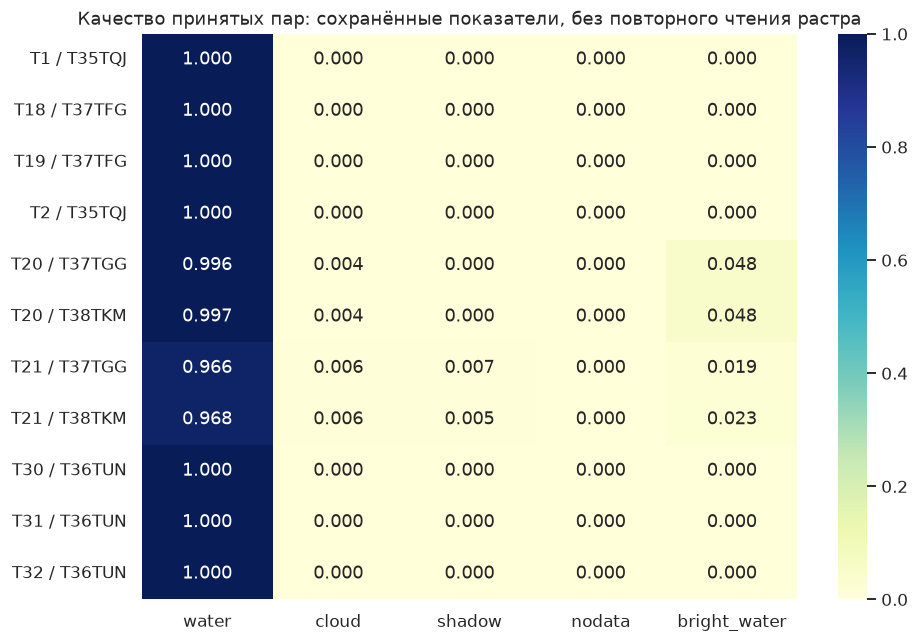

,speed_ms_assumption,time_hours,drift_km
0,0.05,1,0.18
1,0.05,3,0.54
2,0.05,6,1.08
3,0.05,12,2.16
4,0.05,24,4.32
5,0.2,1,0.72
6,0.2,3,2.16
7,0.2,6,4.32
8,0.2,12,8.64
9,0.2,24,17.28


,paired,n,min,median,mean,max,zeros
0,False,24,48.97,191.1,276.5,976,0
1,True,9,67.34,345.3,327.7,587.4,0


,paired,n,min,median,mean,max,zeros
0,False,24,48.97,191.1,276.5,976,0
1,True,9,67.34,345.3,327.7,587.4,0


In [8]:
assert events.event_id.is_unique and set(events.event_id) == set(df.event_id)
assert not pairs.duplicated(["event_id", "scene_id"]).any()
assert set(pairs.event_id).issubset(set(events.event_id))
pair_links = pairs[["event_id", "sample_ids"]].assign(sample_id=pairs.sample_ids.str.split(";")).explode("sample_id")
# Registry writer uses semicolon-separated sample IDs.
assert set(pair_links.sample_id).issubset(set(df.sample_id))
assert set(pairs.loc[pairs.decision == "accepted", "event_id"]) == set(events.loc[events.decision == "accepted", "event_id"])
table("event_pairing_reasons", events.groupby(["source_id", "decision", "reason_code"]).size().rename("events").reset_index())
table("pairing_reasons", pairs.groupby(["collection", "decision", "reason_code"]).size().rename("pairs").reset_index())
accepted_pairs = pairs.loc[pairs.decision == "accepted"].copy()
accepted_pairs["acquisition_day"] = pd.to_datetime(accepted_pairs.scene_datetime, utc=True).dt.strftime("%Y-%m-%d")
acquired = pd.to_datetime(accepted_pairs.scene_datetime, utc=True)
field_day = pd.to_datetime(accepted_pairs.event_date, utc=True)
accepted_pairs["worst_shift_hours_date_only"] = np.maximum(
    (acquired - field_day).dt.total_seconds().abs(),
    (field_day + pd.Timedelta(days=1) - acquired).dt.total_seconds().abs()) / 3600
accepted_pairs["worst_drift_km_date_only"] = accepted_pairs.worst_shift_hours_date_only * CASE_CFG["pairing"]["drift_speed_ms"] * 3.6
accepted_pairs["unknown_time"] = accepted_pairs.time_known != "yes"
accepted_pairs["strict_timing_verified"] = (~accepted_pairs.unknown_time & accepted_pairs.shift_hours.abs().le(CASE_CFG["pairing"]["max_time_shift_hours"]))
pair_stats = {"candidate_pairs": len(pairs), "accepted_pairs": len(accepted_pairs),
    "accepted_events": accepted_pairs.event_id.nunique(), "accepted_tile_scenes": accepted_pairs.scene_id.nunique(),
    "accepted_acquisition_days": accepted_pairs.acquisition_day.nunique(),
    "accepted_point_footprints": int(accepted_pairs.footprint_kind.eq("point").sum()),
    "accepted_events_known_time": accepted_pairs.loc[~accepted_pairs.unknown_time, "event_id"].nunique(),
    "accepted_events_strict_timing_verified": accepted_pairs.loc[accepted_pairs.strict_timing_verified, "event_id"].nunique(),
    "accepted_pairs_missing_bright_water": int(accepted_pairs.bright_water.isna().sum())}
table("pairing_summary", pd.DataFrame(pair_stats.items(), columns=["metric", "value"]))
assert registry_summary["records"] == len(df)
assert registry_summary["selection"]["accepted"] == len(selected)
assert registry_summary["pairs"] == pairs.decision.value_counts().to_dict()
assert registry_summary["events"] == events.decision.value_counts().to_dict()
assert registry_summary["concentration_checks"] == density["check"].value_counts().to_dict()
quality_availability = pairs.groupby("decision").agg(pairs=("scene_id", "size"),
    with_water=("water", "count"), with_cloud=("cloud", "count"), with_bright_water=("bright_water", "count"))
table("pair_quality_availability", quality_availability.reset_index())
display(Markdown("Причины отклонения последовательные: если пара отсеяна по времени, "
                 "проверка растра могла не выполняться. Отсутствие причины cloud не доказывает чистую воду. "
                 "Footprint `point` означает круг неопределённости вокруг центра, а не обследованную полосу."))
table("accepted_pairs_audit", accepted_pairs[["event_id", "scene_id", "collection", "acquisition_day", "time_known", "shift_hours",
    "time_uncertainty_hours", "drift_km_max", "worst_shift_hours_date_only", "worst_drift_km_date_only", "footprint_kind",
    "footprint_area_km2", "water", "cloud", "shadow", "nodata", "bright_water", "strict_timing_verified"]])
quality_thresholds = CASE_CFG["pairing"]
quality_fail = (accepted_pairs.nodata.gt(quality_thresholds["max_footprint_nodata"])
    | (accepted_pairs.cloud + accepted_pairs.shadow).gt(quality_thresholds["max_footprint_cloud"])
    | accepted_pairs.water.lt(quality_thresholds["min_footprint_water"])
    | accepted_pairs.bright_water.gt(quality_thresholds["max_bright_water"]))
assert not quality_fail.any()
coverage = selected.groupby(PROFILE).agg(eligible_events=("event_id", "nunique"))
coverage["paired_events"] = selected.loc[selected.event_id.isin(accepted_pairs.event_id)].groupby(PROFILE).event_id.nunique()
coverage["paired_events"] = coverage.paired_events.fillna(0).astype(int)
coverage["retention_pct"] = 100 * coverage.paired_events / coverage.eligible_events
table("pair_retention", coverage.reset_index())
quality = accepted_pairs[["water", "cloud", "shadow", "nodata", "bright_water"]].copy()
quality.index = accepted_pairs.event_id.str.replace("S4:DOORS3:", "", regex=False) + " / " + accepted_pairs.scene_id.str.extract(r"_(T[A-Z0-9]{5})_")[0]
plt.figure(figsize=(9, 6))
sns.heatmap(quality, annot=True, fmt=".3f", vmin=0, vmax=1, cmap="YlGnBu")
plt.title("Качество принятых пар: сохранённые показатели, без повторного чтения растра")
figure("05_pair_quality")
drift_rows = []
for speed in CFG["drift_speeds_ms"]:
    for hours in [1, 3, 6, 12, 24]:
        drift_rows.append({"speed_ms_assumption": speed, "time_hours": hours, "drift_km": speed * hours * 3.6})
table("drift_scenarios", pd.DataFrame(drift_rows))
# Selection bias is descriptive; there are too few paired events for robust inference.
paired_s4 = selected.loc[selected[PROFILE] == "S4_visual_GT2_5"].copy()
paired_s4["paired"] = paired_s4.event_id.isin(accepted_pairs.event_id)
table("pair_selection_bias_s4", paired_s4.groupby("paired").agg(n=(Y, "size"), min=(Y, "min"),
    median=(Y, "median"), mean=(Y, "mean"), max=(Y, "max"), zeros=(Y, lambda x: int((x == 0).sum()))).reset_index())

## 8. Какие признаки допустимы и где возникает утечка
Разрешённые входы простого пространственного прогноза — широта/долгота.
Дата доступна в реальном запросе, но текущий эксперимент её не использует.
Все остальные поля по умолчанию исключены. Профиль выбирает отдельную модель, не становится
скрытым способом выучить источник. Флаги/notes/идентификаторы способны закодировать ответ.
Гидрометеоусловия можно добавлять только после получения сопоставимого источника при inference.

In [9]:
feature_roles = []
for c in raw.columns:
    if c in {"latitude", "longitude"}:
        role, reason = "used", "пространственный baseline; доступны в запросе"
    elif c == "date_utc":
        role, reason = "available_not_used", "доступна в запросе; короткие экспедиции и смешение года/источника"
    elif c == PROFILE:
        role, reason = "stratification_only", "отдельные метрики и модели для несовместимых протоколов"
    elif "concentration" in c or c.startswith(("reported_", "parent_", "source_object", "source_reported")) or c in {"items_count", "density_numerator_items", "zero_scope"}:
        role, reason = "forbidden_target_leakage", "ответ, его производная или контекст родительской метки"
    elif c in {"sea_state_beaufort", "wind_speed_kn"}:
        role, reason = "not_available_at_inference", "полевое измерение; нужен независимый слой с сопоставимыми единицами"
    else:
        role, reason = "excluded_metadata", "идентификатор/происхождение/метод/геометрия учёта; не вход текущей модели"
    feature_roles.append({"field": c, "role": role, "reason": reason})
table("feature_roles", pd.DataFrame(feature_roles))
train_rows, test_rows = train_test_split(np.arange(len(df)), test_size=.2, random_state=CFG["seed"])
overlap = set(df.iloc[train_rows].event_id) & set(df.iloc[test_rows].event_id)
naive_leakage = {"test_rows": len(test_rows), "shared_events": len(overlap),
                "test_rows_with_event_seen_in_train": int(df.iloc[test_rows].event_id.isin(overlap).sum())}
table("naive_row_split_leakage", pd.DataFrame(naive_leakage.items(), columns=["metric", "value"]))

,field,role,reason
0,sample_id,excluded_metadata,идентификатор/происхождение/метод/геометрия уч...
1,source_id,excluded_metadata,идентификатор/происхождение/метод/геометрия уч...
2,source_short,excluded_metadata,идентификатор/происхождение/метод/геометрия уч...
3,source_doi,excluded_metadata,идентификатор/происхождение/метод/геометрия уч...
4,source_license,excluded_metadata,идентификатор/происхождение/метод/геометрия уч...
5,region,excluded_metadata,идентификатор/происхождение/метод/геометрия уч...
6,sea_area,excluded_metadata,идентификатор/происхождение/метод/геометрия уч...
7,record_type,excluded_metadata,идентификатор/происхождение/метод/геометрия уч...
8,sampling_method,excluded_metadata,идентификатор/происхождение/метод/геометрия уч...
9,platform,excluded_metadata,идентификатор/происхождение/метод/геометрия уч...


,metric,value
0,test_rows,187
1,shared_events,114
2,test_rows_with_event_seen_in_train,162


,metric,value
0,test_rows,187
1,shared_events,114
2,test_rows_with_event_seen_in_train,162


## 9. Фиксируем пространственно-временные группы до обучения
Связываем события, если расстояние между центрами ≤50 км И разница дат ≤3 суток,
либо у них общая принятая сцена. Для одного источника все принятые события одного дня съёмки
объединяем консервативно, включая соседние тайлы. Компоненты связности не разрываются между folds.
Близость транзитивна: цепочка соседей может образовать большую группу. Это намеренно.
Порог — заранее заданный сценарий, не оценённая длина корреляции океана; показываем чувствительность.
Центры не заменяют пересечение полных footprint: для финального split нужны полосы, течения и буферы.

Grouped CV ниже — **исследовательская проверка**, не нетронутый финальный test.
Нет подбора гиперпараметров или выбора split по качеству. После EDA нужен новый внешний holdout.

,km,days,measurement_profile,groups,largest_group,largest_group_fraction
0,25,1,S1_trawl_5_to_50,76,2,0.0241
1,25,1,S2_visual_GT2,61,2,0.03175
2,25,1,S3_visual_GT2,13,12,0.2927
3,25,1,S4_visual_GT2_5,15,5,0.1515
4,25,3,S1_trawl_5_to_50,76,2,0.0241
5,25,3,S2_visual_GT2,61,2,0.03175
6,25,3,S3_visual_GT2,12,15,0.3659
7,25,3,S4_visual_GT2_5,15,5,0.1515
8,25,7,S1_trawl_5_to_50,76,2,0.0241
9,25,7,S2_visual_GT2,61,2,0.03175


,measurement_profile,n,groups
0,S1_trawl_5_to_50,83,55
1,S2_visual_GT2,63,41
2,S3_visual_GT2,41,8
3,S4_visual_GT2_5,33,9


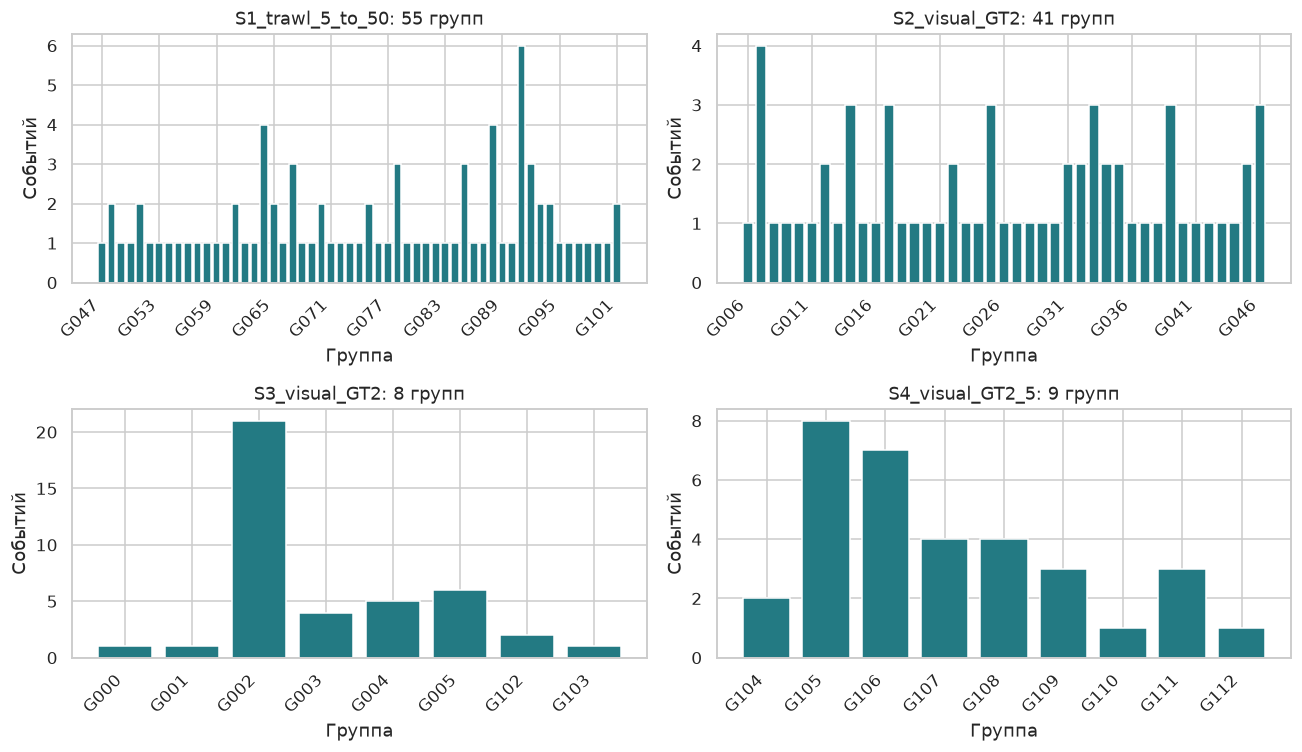

In [10]:
coordinates = np.radians(selected[["latitude", "longitude"]].to_numpy(dtype=float))
dist_km = haversine_distances(coordinates) * 6371.0088
day_number = selected.date.dt.as_unit("ns").astype("int64").to_numpy() / (86400 * 1e9)
delta_days = np.abs(day_number[:, None] - day_number[None, :])
scene_edges = np.eye(len(selected), dtype=bool)
event_to_idx = dict(zip(selected.event_id, selected.index))
for col in ["scene_id", "acquisition_day"]:
    for _, g in accepted_pairs.groupby(col):
        idx = [event_to_idx[e] for e in g.event_id.unique() if e in event_to_idx]
        scene_edges[np.ix_(idx, idx)] = True

def make_groups(km, days):
    adjacency = ((dist_km <= km) & (delta_days <= days)) | scene_edges
    _, labels = connected_components(csr_matrix(adjacency), directed=False)
    return labels, adjacency

group_labels, adjacency = make_groups(CFG["spatial_group_km"], CFG["temporal_group_days"])
selected["group"] = [f"G{x:03d}" for x in group_labels]
sensitivity = []
for km in CFG["group_distance_sensitivity_km"]:
    for days in CFG["group_time_sensitivity_days"]:
        groups, _ = make_groups(km, days)
        for profile, g in selected.assign(sensitivity_group=groups).groupby(PROFILE):
            sizes = g.groupby("sensitivity_group").size()
            sensitivity.append({"km": km, "days": days, PROFILE: profile, "groups": len(sizes), "largest_group": sizes.max(),
                                "largest_group_fraction": sizes.max() / len(g)})
table("grouping_sensitivity", pd.DataFrame(sensitivity))
group_summary = table("group_summary", selected.groupby(PROFILE).agg(n=("event_id", "size"), groups=("group", "nunique")).reset_index())
table("event_groups", selected[["sample_id", "event_id", PROFILE, "group", "latitude", "longitude", "date_utc"]], show=False)
group_sizes = selected.groupby([PROFILE, "group"]).size().rename("events").reset_index()
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (profile, g) in zip(axes.flat, group_sizes.groupby(PROFILE)):
    positions = np.arange(len(g))
    ax.bar(positions, g.events, color="#237a83")
    ticks = positions[::max(1, int(np.ceil(len(g) / 10)))]
    ax.set_xticks(ticks, g.group.iloc[ticks], rotation=45, ha="right")
    ax.set(title=f"{profile}: {len(g)} групп", ylabel="Событий", xlabel="Группа")
figure("06_group_sizes")

## 10. Базовые прогнозы концентрации на одинаковых folds
Сравниваем mean(train), median(train), kNN по географическому расстоянию (k=5,
веса 1/d, обучение на log1p(C), обратное преобразование expm1).
Это полевые пространственные baselines, не спутниковая модель и не детектор.
kNN в лог-пространстве не оценивает арифметическое условное среднее без поправки смещения.
Масштабирование/выбор k по проверочным меткам не проводится.

Метрики: MAE, RMSE в шт./км², median AE, RMSLE, R², signed bias.
MAPE исключена из-за нулевых целей. Результаты отдельных профилей не сводим в общую метрику.
95% интервалы MAE получаем bootstrap целых групп по фиксированным OOF-предсказаниям;
они не учитывают повторное обучение и перенос на другую акваторию. При малом числе групп ненадёжны.
Дополнительно проверяем покрытие простого диапазона train p10–p90: это **некалиброванный**
предиктивный ориентир, не доверительный интервал измерения.

In [11]:
predictions, memberships, split_checks, skipped = [], [], [], []
for profile, g in selected.groupby(PROFILE):
    n_groups = g.group.nunique()
    if n_groups < 2:
        skipped.append({PROFILE: profile, "reason": "меньше двух независимых групп", "groups": n_groups})
        continue
    splitter = GroupKFold(n_splits=min(CFG["folds"], n_groups))
    for fold, (train_idx, test_idx) in enumerate(splitter.split(g, groups=g.group)):
        train, test = g.iloc[train_idx], g.iloc[test_idx]
        tr_global, te_global = train.index.to_numpy(), test.index.to_numpy()
        event_overlap = len(set(train.event_id) & set(test.event_id))
        group_overlap = len(set(train.group) & set(test.group))
        train_scenes = set(accepted_pairs.loc[accepted_pairs.event_id.isin(train.event_id), "scene_id"])
        test_scenes = set(accepted_pairs.loc[accepted_pairs.event_id.isin(test.event_id), "scene_id"])
        cross_edges = int(adjacency[np.ix_(tr_global, te_global)].sum())
        assert event_overlap == group_overlap == len(train_scenes & test_scenes) == cross_edges == 0
        split_checks.append({PROFILE: profile, "fold": fold, "train_n": len(train), "test_n": len(test),
            "train_groups": train.group.nunique(), "test_groups": test.group.nunique(),
            "event_overlap": event_overlap, "group_overlap": group_overlap, "scene_overlap": len(train_scenes & test_scenes),
            "neighbor_edges_across_split": cross_edges, "nearest_train_test_km": dist_km[np.ix_(tr_global, te_global)].min()})
        for role, part in [("train", train), ("test", test)]:
            for _, row in part.iterrows():
                scene_ids = sorted(accepted_pairs.loc[accepted_pairs.event_id == row.event_id, "scene_id"].unique())
                memberships.append({PROFILE: profile, "fold": fold, "role": role, "event_id": row.event_id,
                    "sample_id": row.sample_id, "group": row.group, "scene_ids": ";".join(scene_ids)})
        model = KNeighborsRegressor(n_neighbors=min(CFG["knn_neighbors"], len(train)), metric="haversine", algorithm="brute", weights="distance")
        model.fit(np.radians(train[["latitude", "longitude"]].to_numpy(dtype=float)), np.log1p(train[Y]))
        outputs = {"train_mean": np.full(len(test), train[Y].mean()), "train_median": np.full(len(test), train[Y].median()),
                   "spatial_knn_log1p": np.expm1(model.predict(np.radians(test[["latitude", "longitude"]].to_numpy(dtype=float))))}
        lo, hi = train[Y].quantile([.1, .9])
        for name, prediction in outputs.items():
            for (_, row), value in zip(test.iterrows(), prediction):
                predictions.append({PROFILE: profile, "model": name, "fold": fold, "event_id": row.event_id,
                    "sample_id": row.sample_id, "group": row.group, "y_true": row[Y], "y_pred": value,
                    "train_p10": lo, "train_p90": hi, "interval_covered": lo <= row[Y] <= hi})
pred = pd.DataFrame(predictions)
pred["error"] = pred.y_pred - pred.y_true
pred["abs_error"] = pred.error.abs()
table("oof_predictions", pred, show=False)
table("cv_memberships", pd.DataFrame(memberships), show=False)
table("split_integrity", pd.DataFrame(split_checks))
table("skipped_profiles", pd.DataFrame(skipped, columns=[PROFILE, "reason", "groups"]))

def metric_values(g):
    return {"MAE": mean_absolute_error(g.y_true, g.y_pred), "RMSE": np.sqrt(mean_squared_error(g.y_true, g.y_pred)),
            "median_AE": g.abs_error.median(), "RMSLE": np.sqrt(np.mean((np.log1p(g.y_pred) - np.log1p(g.y_true)) ** 2)),
            "R2": r2_score(g.y_true, g.y_pred) if len(g) >= 2 and g.y_true.nunique() > 1 else np.nan,
            "bias": g.error.mean()}

metric_rows, fold_rows = [], []
for (profile, name), g in pred.groupby([PROFILE, "model"]):
    rng = np.random.default_rng(CFG["seed"])
    grouped_errors = [x.abs_error.to_numpy() for _, x in g.groupby("group")]
    boot = [np.concatenate([grouped_errors[i] for i in rng.integers(0, len(grouped_errors), len(grouped_errors))]).mean()
            for _ in range(CFG["bootstrap_repeats"])]
    metric_rows.append({PROFILE: profile, "model": name, "n": len(g), "groups": g.group.nunique(),
        **metric_values(g), "MAE_ci025": np.quantile(boot, .025), "MAE_ci975": np.quantile(boot, .975),
        "train_p10_p90_coverage": g.interval_covered.mean(), "mean_interval_width": (g.train_p90 - g.train_p10).mean()})
    for fold, fg in g.groupby("fold"):
        fold_rows.append({PROFILE: profile, "model": name, "fold": fold, "n": len(fg), **metric_values(fg)})
metrics = table("baseline_metrics", pd.DataFrame(metric_rows))
table("fold_metrics", pd.DataFrame(fold_rows), show=False)
# Every evaluated event receives exactly one prediction per model, from its held-out fold.
assert not pred.duplicated(["event_id", "model"]).any()
assert (pred.groupby("event_id").size() == 3).all()
assert np.isfinite(pred[["y_true", "y_pred"]]).all().all() and (pred.y_pred >= 0).all()
assert pred.groupby([PROFILE, "model"]).event_id.nunique().groupby(level=0).nunique().eq(1).all()
table("baseline_mae_comparison", metrics.pivot(index=PROFILE, columns="model", values="MAE").reset_index())

,measurement_profile,fold,train_n,test_n,train_groups,test_groups,event_overlap,group_overlap,scene_overlap,neighbor_edges_across_split,nearest_train_test_km
0,S1_trawl_5_to_50,0,66,17,45,10,0,0,0,0,50.21
1,S1_trawl_5_to_50,1,66,17,44,11,0,0,0,0,50.56
2,S1_trawl_5_to_50,2,66,17,43,12,0,0,0,0,50.29
3,S1_trawl_5_to_50,3,67,16,44,11,0,0,0,0,50.21
4,S1_trawl_5_to_50,4,67,16,44,11,0,0,0,0,50.75
5,S2_visual_GT2,0,50,13,33,8,0,0,0,0,51.07
6,S2_visual_GT2,1,50,13,33,8,0,0,0,0,52.17
7,S2_visual_GT2,2,50,13,32,9,0,0,0,0,52.06
8,S2_visual_GT2,3,51,12,33,8,0,0,0,0,52.68
9,S2_visual_GT2,4,51,12,33,8,0,0,0,0,51.07


,measurement_profile,reason,groups


,measurement_profile,model,n,groups,MAE,RMSE,median_AE,RMSLE,R2,bias,MAE_ci025,MAE_ci975,train_p10_p90_coverage,mean_interval_width
0,S1_trawl_5_to_50,spatial_knn_log1p,83,55,352.2,514.7,260.8,0.7837,-0.05982,-100.3,269.5,448.1,0.759,"1,215"
1,S1_trawl_5_to_50,train_mean,83,55,415.5,520.8,363.5,0.9256,-0.08509,0.5289,345.5,496.5,0.759,"1,215"
2,S1_trawl_5_to_50,train_median,83,55,423.1,541,353,0.9088,-0.1712,-102,349.4,512.8,0.759,"1,215"
3,S2_visual_GT2,spatial_knn_log1p,63,41,23.19,30.45,19.23,0.6452,0.4963,-5.671,18.78,28.21,0.746,89.78
4,S2_visual_GT2,train_mean,63,41,35.15,43.83,30.45,0.868,-0.04357,0.05042,28.26,42.81,0.746,89.78
5,S2_visual_GT2,train_median,63,41,34.04,47.24,21.76,0.8372,-0.2121,-16.18,25.45,44.55,0.746,89.78
6,S3_visual_GT2,spatial_knn_log1p,41,8,16.29,34.43,8.997,0.6258,0.02447,-7.157,6.48,25.31,0.6829,41.19
7,S3_visual_GT2,train_mean,41,8,20.41,35.95,15.79,0.7834,-0.06367,-1.9,14.92,31.73,0.6829,41.19
8,S3_visual_GT2,train_median,41,8,21.91,37.65,12.7,0.8193,-0.1664,-10.73,12.42,29.86,0.6829,41.19
9,S4_visual_GT2_5,spatial_knn_log1p,33,9,160.9,234.2,98.98,0.7525,-0.04868,-40.01,90.7,263.3,0.697,519.5


model,measurement_profile,spatial_knn_log1p,train_mean,train_median
0,S1_trawl_5_to_50,352.2,415.5,423.1
1,S2_visual_GT2,23.19,35.15,34.04
2,S3_visual_GT2,16.29,20.41,21.91
3,S4_visual_GT2_5,160.9,191.8,180.8


model,measurement_profile,spatial_knn_log1p,train_mean,train_median
0,S1_trawl_5_to_50,352.2,415.5,423.1
1,S2_visual_GT2,23.19,35.15,34.04
2,S3_visual_GT2,16.29,20.41,21.91
3,S4_visual_GT2_5,160.9,191.8,180.8


## 11. Разбор ошибок и чувствительность вывода
Сохраняем все out-of-fold ответы, лучшие и худшие случаи каждого профиля.
Проверяем, сосредоточена ли ошибка в верхнем хвосте. Удаление тяжёлых случаев из test
недопустимо; сравнение ниже только объясняет ошибки на общей проверочной выборке.
Сценарий ±10/20% площади описывает чувствительность C=N/A, а не измеренную точность источника.

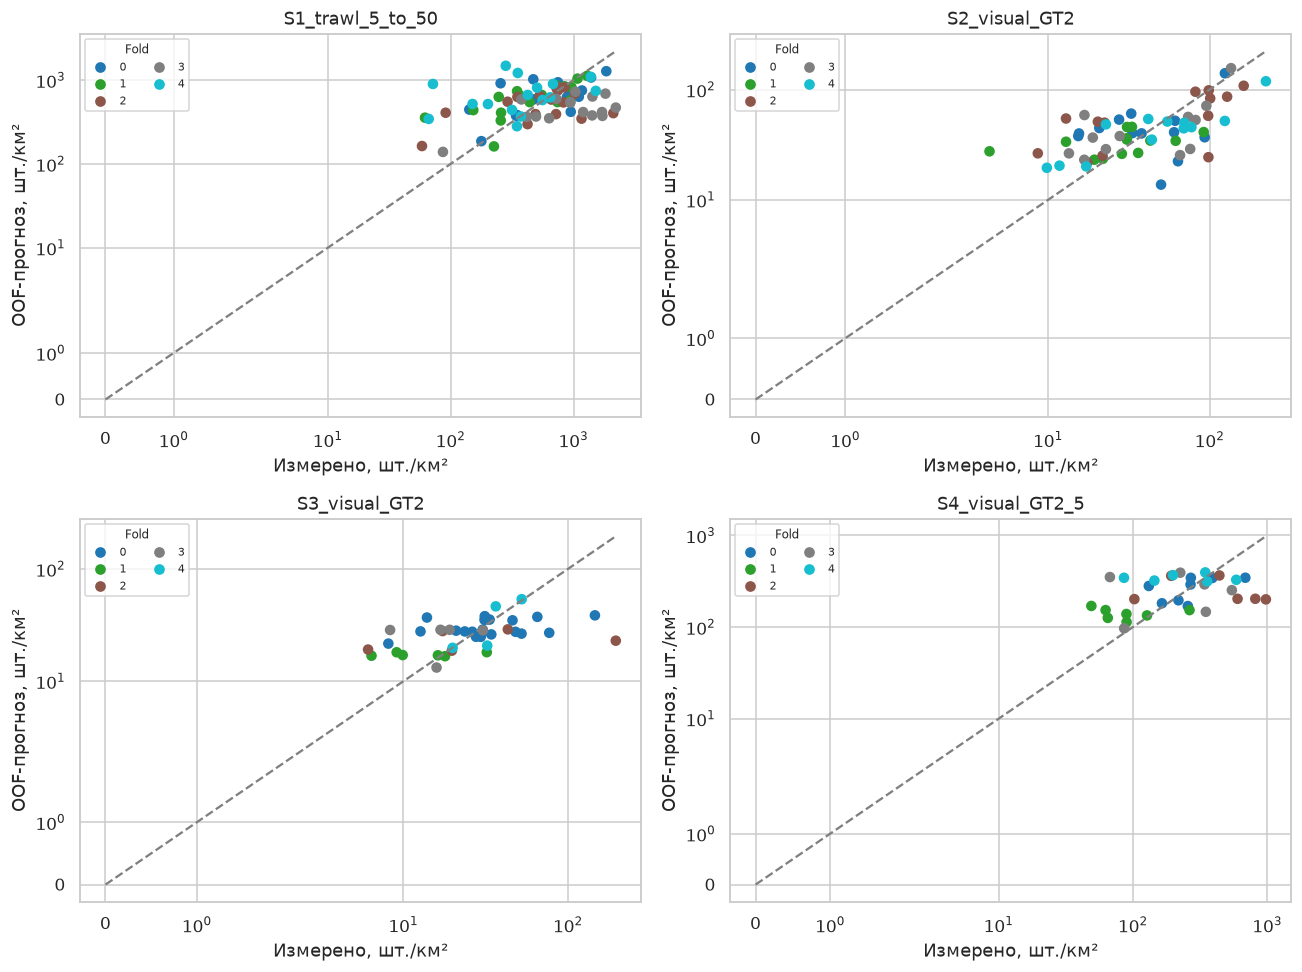

,measurement_profile,model,fold,event_id,sample_id,group,y_true,y_pred,...,train_p90,interval_covered,error,abs_error,date_utc,latitude,longitude,quality_flags
57,S1_trawl_5_to_50,spatial_knn_log1p,3,S1:41.3,MPL-0654,G078,"2,209",469.3,...,"1,166",False,"-1,740","1,740",2015-08-07,30.97,-137.4,NaN
38,S1_trawl_5_to_50,spatial_knn_log1p,2,S1:19.4,MPL-0590,G064,"2,109",402.8,...,"1,422",False,"-1,706","1,706",2015-08-01,30.01,-142.3,NaN
55,S1_trawl_5_to_50,spatial_knn_log1p,3,S1:25.3,MPL-0607,G065,"1,719",373.6,...,"1,166",False,"-1,346","1,346",2015-08-03,30,-139.3,NaN
58,S1_trawl_5_to_50,spatial_knn_log1p,3,S1:42.3,MPL-0656,G078,"1,707",414.9,...,"1,166",False,"-1,292","1,292",2015-08-07,30.99,-137.9,NaN
79,S1_trawl_5_to_50,spatial_knn_log1p,4,S1:50.3,MPL-0687,G085,280.9,"1,480",...,"1,421",True,"1,199","1,199",2015-08-09,31,-142.4,NaN
207,S4_visual_GT2_5,spatial_knn_log1p,2,S4:DOORS3:T25,MPL-0927,G108,976,200,...,451.7,False,-776,776,2024-06-11,42.04,41.68,all_litter_not_plastic;numerator_area_unavaila...
204,S4_visual_GT2_5,spatial_knn_log1p,2,S4:DOORS3:T22,MPL-0924,G108,814.1,203.1,...,451.7,False,-610.9,610.9,2024-06-09,42.18,41.58,all_litter_not_plastic;numerator_area_unavaila...
205,S4_visual_GT2_5,spatial_knn_log1p,2,S4:DOORS3:T24,MPL-0925,G108,600.5,202.9,...,451.7,False,-397.6,397.6,2024-06-10,42.2,41.57,all_litter_not_plastic;numerator_area_unavaila...
194,S4_visual_GT2_5,spatial_knn_log1p,0,S4:DOORS3:T3,MPL-0912,G105,686.1,344.6,...,595.3,False,-341.4,341.4,2024-06-03,43.13,32.45,all_litter_not_plastic;numerator_area_unavaila...
208,S4_visual_GT2_5,spatial_knn_log1p,3,S4:DOORS3:T19,MPL-0920,G107,544.7,252.3,...,634.7,True,-292.4,292.4,2024-06-05,41.77,41.25,all_litter_not_plastic;numerator_area_unavaila...


,measurement_profile,model,fold,event_id,sample_id,group,y_true,y_pred,...,train_p90,interval_covered,error,abs_error,date_utc,latitude,longitude,quality_flags
184,S3_visual_GT2,spatial_knn_log1p,4,S3:HE460_MarLitter_transect01,MPL-0779,G102,19.9,19.83,...,57.36,True,-0.06983,0.06983,2016-04-08,54.24,7.92,all_litter_not_plastic
118,S2_visual_GT2,spatial_knn_log1p,2,S2:MSM41_litter-T54,MPL-0443,G039,98.66,98.34,...,93.32,False,-0.3271,0.3271,2015-04-22,30.93,-59.4,author_area_replaces_endpoint_distance
170,S3_visual_GT2,spatial_knn_log1p,1,S3:HE419_MarLitter_transect35,MPL-0185,G005,16.2,17.01,...,59.98,True,0.812,0.812,2014-04-12,53.84,6.991,all_litter_not_plastic
173,S3_visual_GT2,spatial_knn_log1p,2,S3:HE419_MarLitter_transect32,MPL-0146,G004,19.7,18.71,...,52.25,True,-0.9923,0.9923,2014-04-11,54.41,7.945,all_litter_not_plastic
97,S2_visual_GT2,spatial_knn_log1p,1,S2:MSM41_litter-T12,MPL-0233,G012,21.81,23.54,...,124.1,True,1.727,1.727,2015-04-05,25.89,-69.95,author_area_replaces_endpoint_distance
86,S2_visual_GT2,spatial_knn_log1p,0,S2:MSM41_litter-T7,MPL-0220,G007,37.89,40.03,...,103,True,2.143,2.143,2015-04-03,29.43,-69.94,author_area_replaces_endpoint_distance
24,S1_trawl_5_to_50,spatial_knn_log1p,1,S1:38.3,MPL-0642,G075,846.4,841.2,...,"1,472",True,-5.188,5.188,2015-08-06,30.99,-136,NaN
50,S1_trawl_5_to_50,spatial_knn_log1p,2,S1:78.3,MPL-0770,G100,748,754,...,"1,422",True,5.971,5.971,2015-08-17,32.99,-139.6,NaN
75,S1_trawl_5_to_50,spatial_knn_log1p,4,S1:34.4,MPL-0631,G072,373.2,367.3,...,"1,421",True,-5.972,5.972,2015-08-05,30,-134.3,NaN
197,S4_visual_GT2_5,spatial_knn_log1p,1,S4:DOORS3:T15,MPL-0915,G106,127.1,133.7,...,643.3,True,6.554,6.554,2024-06-04,42.3,37.88,all_litter_not_plastic;numerator_area_unavaila...


,measurement_profile,diagnostic_subset,n,MAE,RMSE,median_AE,RMSLE,R2,bias
0,S1_trawl_5_to_50,top_10pct_y,9,"1,155","1,217","1,131",1.222,-20.29,"-1,155"
1,S1_trawl_5_to_50,remaining_y,74,254.6,341.9,214.3,0.7123,0.05086,27.97
2,S2_visual_GT2,top_10pct_y,7,46.67,55.66,42.06,0.4655,-1.282,-36.1
3,S2_visual_GT2,remaining_y,56,20.25,25.61,17.77,0.6642,0.1617,-1.868
4,S3_visual_GT2,top_10pct_y,5,71.66,94.2,49.92,1.223,-1.975,-71.08
5,S3_visual_GT2,remaining_y,36,8.602,10.84,7.692,0.4882,0.1741,1.722
6,S4_visual_GT2_5,top_10pct_y,4,531.5,559,504.3,1.231,-14.59,-531.5
7,S4_visual_GT2_5,remaining_y,29,109.8,138.9,86.91,0.6599,0.07105,27.77


,measurement_profile,positive_means_knn_better,gain_ci025,gain_ci975,groups
0,S1_trawl_5_to_50,70.87,22.63,124.3,55
1,S2_visual_GT2,10.85,3.848,18.66,41
2,S3_visual_GT2,5.616,2.732,7.921,8
3,S4_visual_GT2_5,19.85,-27.91,60.24,9


,relative_area_error_assumed,C_lower_over_nominal,C_upper_over_nominal
0,0.1,0.9091,1.111
1,0.2,0.8333,1.25


,relative_area_error_assumed,C_lower_over_nominal,C_upper_over_nominal
0,0.1,0.9091,1.111
1,0.2,0.8333,1.25


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (profile, g) in zip(axes.flat, pred.loc[pred.model == "spatial_knn_log1p"].groupby(PROFILE)):
    sc = ax.scatter(g.y_true, g.y_pred, c=g.fold, cmap="tab10", s=35)
    handles, labels = sc.legend_elements()
    ax.legend(handles, labels, title="Fold", fontsize=7, title_fontsize=8, loc="upper left", ncol=2)
    limit = max(g.y_true.max(), g.y_pred.max())
    ax.plot([0, limit], [0, limit], color="grey", linestyle="--")
    ax.set(title=profile, xlabel="Измерено, шт./км²", ylabel="OOF-прогноз, шт./км²", xscale="symlog", yscale="symlog")
figure("07_oof_predictions")
knn = pred.loc[pred.model == "spatial_knn_log1p"].copy()
errors = knn.merge(selected[["event_id", "date_utc", "latitude", "longitude", "quality_flags"]], on="event_id", validate="one_to_one")
table("worst_errors", errors.sort_values("abs_error", ascending=False).groupby(PROFILE).head(5))
table("best_errors", errors.sort_values("abs_error").groupby(PROFILE).head(3))
tails = []
for profile, g in knn.groupby(PROFILE):
    threshold = g.y_true.quantile(.9)
    for label, subset in [("top_10pct_y", g.loc[g.y_true >= threshold]), ("remaining_y", g.loc[g.y_true < threshold])]:
        tails.append({PROFILE: profile, "diagnostic_subset": label, "n": len(subset), **metric_values(subset)})
table("tail_error_diagnostics", pd.DataFrame(tails))
paired_improvements = []
for profile, g in pred.groupby(PROFILE):
    wide = g.pivot(index=["event_id", "group"], columns="model", values="abs_error").reset_index()
    wide["mae_gain_knn_vs_median"] = wide.train_median - wide.spatial_knn_log1p
    arrays = [z.mae_gain_knn_vs_median.to_numpy() for _, z in wide.groupby("group")]
    rng = np.random.default_rng(CFG["seed"])
    boot = [np.concatenate([arrays[i] for i in rng.integers(0, len(arrays), len(arrays))]).mean()
            for _ in range(CFG["bootstrap_repeats"])]
    paired_improvements.append({PROFILE: profile, "positive_means_knn_better": wide.mae_gain_knn_vs_median.mean(),
        "gain_ci025": np.quantile(boot, .025), "gain_ci975": np.quantile(boot, .975), "groups": len(arrays)})
gain = table("paired_mae_gain", pd.DataFrame(paired_improvements))
table("area_uncertainty_scenarios", pd.DataFrame([{"relative_area_error_assumed": e,
    "C_lower_over_nominal": 1 / (1 + e), "C_upper_over_nominal": 1 / (1 - e)} for e in CFG["area_relative_scenarios"]]))

## 12. Что обучать дальше и что требуется по критериям

**Детектор.** Начать с MARIDA: изображения, маски классов и уверенности, исходный split.
Сверить сцену/дату и соседние патчи между частями; при пересечениях построить отдельный строгий split
и не выдавать его за оригинальный benchmark. Положительный класс — marine debris, не автоматически
чистый пластик. Неразмеченные пиксели игнорировать; размеченный сложный фон сохранить по классам.
Сначала спектральный Random Forest и пороговый baseline, затем небольшой U-Net, если baseline и
визуальная проверка масок работают. Threshold выбирать на validation, один и тот же test использовать
для precision/recall/F1/IoU, PR-AUC и разбора FP/FN по водорослям, пене, судам, мутной воде и бликам.
Confidence-маски нужны для sensitivity-анализа, не для превращения неизвестного фона в отрицательный.
Указать исходное разрешение каналов, resampling масок nearest-neighbor, reflectance scale/offset и
алгоритм атмосферной коррекции. SCL пригодность и класс debris — отдельные слои.
Источники: [MARIDA v1](https://zenodo.org/records/5151941),
[статья и baselines](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0262247).
MADOS оставить кандидатом для внешней проверки после сверки сцен, классов и происхождения:
[MADOS](https://zenodo.org/records/10664073). Локальные манифесты не заменяют скачивание и проверку архивов.

**Концентрация.** Сохранить независимые профили и честный полевой baseline. Для следующего опыта
начать с настоящего пластика S1/S2 и получить доступные при inference ковариаты: расстояние до берега,
рек/портов, течения и ветер с датой/версией. Простая регуляризованная модель на log1p(C) или
Tweedie допускается только после проверки ненулевых групп, экспозиции/площади и достаточности данных.
Не включать N, площади с целью реконструировать C или полевые условия, которых нет при применении.
Число предметов и площадь разрешены в отдельном **калькуляторе измерения** C=N/A, но не как признаки
модели, заявленной для прогноза по спутнику. Полевая модель сама по себе не подтверждает спутниковый перенос.

**Совместная калибровка.** Восстановить время DOORS, исходную геометрию и сегменты прерванных
трансект S2. Повторно получить маски/каналы и оценить дрейф с направлением/неопределённостью.
Извлекать признаки агрегированно по реальной области наблюдения, с учётом полосы и переноса за время сдвига.
Площадь маски и FDI не конвертировать в шт./км² без независимых измерений.
Нужны дополнительные совместные кампании с пластик-специфическим составом, временем и эталонной площадью.
Не расширять временное окно только ради увеличения train. Девять событий одной кампании не дают
доказательства переноса на другие моря. До подтверждения использовать «исследовательская оценка»
или «концентрация недоступна» и явно отделять измерения от прогнозов.

**Проверка.** Зафиксировать новый внешний test по сценам/кампаниям до подбора моделей.
Разделить интервалы ошибки измерения, неопределённость OOF-метрик и предиктивные интервалы.
Conformal/calibration оценивать на отдельных группах только после расширения данных;
bootstrap нескольких групп не делает выборку репрезентативной.

In [13]:
requirements = pd.DataFrame([
    ("О1", "15", "Определение цели", "Отдельные scope/profile, единицы, решения для каждой строки", "S3/S4 остаются всем мусором"),
    ("О2", "15", "Количественные выводы", "C=N/A, grouped OOF, bootstrap MAE, сценарии площади/дрейфа", "нет подтверждённой спутниковой калибровки"),
    ("О3", "10", "Зоны загрязнения", "Аудит наличия снимков/масок", "нет локальной разметки и предсказаний детектора"),
    ("О4", "5", "Польза карты", "Вывод о статусах, единицах и происхождении", "UI в этом EDA не проверялся"),
    ("О5", "5", "Аргументация", "Notebook, ошибки, ограничения, план экспериментов", "защита команды отдельно"),
    ("О6", "5", "Дополнительные функции", "Сценарии дрейфа", "это не реализованный прогноз течений"),
    ("Т1", "10", "Подготовка", "Независимый отбор, аудит реестра и неизвестного времени", "повторное чтение сцен и сегменты S2 ещё нужны"),
    ("Т2", "15", "Детектор", "План baseline/main и классов", "precision/recall/F1/IoU недоступны"),
    ("Т3", "15", "Концентрация", "Baseline MAE/RMSE, OOF-ответы, контроль C=N/A", "основная модель и внешний test ещё нужны"),
    ("Т4", "7", "Воспроизводимость", "Хеши, окружение, config, IDs/folds, контроль пересечений", "EDA CV не финальный test"),
    ("Т5", "3", "Интеграция", "Экспорт таблиц и отчёта", "интеграционный сценарий модели/UI не запускался"),
], columns=["criterion", "max_points", "requirement", "evidence_in_eda", "remaining"])
table("criteria_coverage", requirements)

,criterion,max_points,requirement,evidence_in_eda,remaining
0,О1,15,Определение цели,"Отдельные scope/profile, единицы, решения для ...",S3/S4 остаются всем мусором
1,О2,15,Количественные выводы,"C=N/A, grouped OOF, bootstrap MAE, сценарии пл...",нет подтверждённой спутниковой калибровки
2,О3,10,Зоны загрязнения,Аудит наличия снимков/масок,нет локальной разметки и предсказаний детектора
3,О4,5,Польза карты,"Вывод о статусах, единицах и происхождении",UI в этом EDA не проверялся
4,О5,5,Аргументация,"Notebook, ошибки, ограничения, план экспериментов",защита команды отдельно
5,О6,5,Дополнительные функции,Сценарии дрейфа,это не реализованный прогноз течений
6,Т1,10,Подготовка,"Независимый отбор, аудит реестра и неизвестног...",повторное чтение сцен и сегменты S2 ещё нужны
7,Т2,15,Детектор,План baseline/main и классов,precision/recall/F1/IoU недоступны
8,Т3,15,Концентрация,"Baseline MAE/RMSE, OOF-ответы, контроль C=N/A",основная модель и внешний test ещё нужны
9,Т4,7,Воспроизводимость,"Хеши, окружение, config, IDs/folds, контроль п...",EDA CV не финальный test


,criterion,max_points,requirement,evidence_in_eda,remaining
0,О1,15,Определение цели,"Отдельные scope/profile, единицы, решения для ...",S3/S4 остаются всем мусором
1,О2,15,Количественные выводы,"C=N/A, grouped OOF, bootstrap MAE, сценарии пл...",нет подтверждённой спутниковой калибровки
2,О3,10,Зоны загрязнения,Аудит наличия снимков/масок,нет локальной разметки и предсказаний детектора
3,О4,5,Польза карты,"Вывод о статусах, единицах и происхождении",UI в этом EDA не проверялся
4,О5,5,Аргументация,"Notebook, ошибки, ограничения, план экспериментов",защита команды отдельно
5,О6,5,Дополнительные функции,Сценарии дрейфа,это не реализованный прогноз течений
6,Т1,10,Подготовка,"Независимый отбор, аудит реестра и неизвестног...",повторное чтение сцен и сегменты S2 ещё нужны
7,Т2,15,Детектор,План baseline/main и классов,precision/recall/F1/IoU недоступны
8,Т3,15,Концентрация,"Baseline MAE/RMSE, OOF-ответы, контроль C=N/A",основная модель и внешний test ещё нужны
9,Т4,7,Воспроизводимость,"Хеши, окружение, config, IDs/folds, контроль п...",EDA CV не финальный test


## 13. Итог по фактическому запуску
Следующее заключение формируется из вычисленных таблиц. Источники: исходный CSV/README,
PDF постановки/критериев, конфигурация backend и сохранённый реестр. Хеши входов — `input_hashes.csv`.

In [14]:
summary_lines = [
    "# Выводы EDA Littora", "",
    f"Проанализировано {len(df)} строк, {len(raw.columns)} полей и {df.event_id.nunique()} событий; "
    f"{df.date.min():%Y-%m-%d} — {df.date.max():%Y-%m-%d}.", "",
    "## Что пригодно для анализа",
    f"Отбор из backend независимо воспроизведён без расхождений: {len(selected)} целевых событий. "
    "Остальные строки остаются в аудите; их нельзя считать независимыми метками концентрации.", "",
    target_counts.to_markdown(index=False), "",
    "S1/S2 относятся к пластику, S3/S4 — ко всему мусору. Общая регрессия по всем строкам недопустима. "
    "Пропуски не заменяются нулями; `reported_*`, `parent_*`, counts и производные исключены из признаков.", "",
    f"Среди выбранных событий нулей: {int(selected[Y].eq(0).sum())}; в полном CSV — {int(df[Y].eq(0).sum())}, "
    "причём нули относятся к отдельным scope/категориям. В выбранных целях нет подтверждённых "
    "нулевых контрольных случаев: качество распознавания незагрязнённых участков этим набором не проверяется.", "",
    f"Найдено {checks['duplicate_rows_without_sample_id']} повторных строк при сравнении без sample_id "
    f"({int(duplicates.sum())} строк в совпадающих группах). Это объектные контексты, "
    "исключённые из целей. Не удаляем их без проверки исходных объектных идентификаторов.", "",
    "## Качество измерений",
    density["check"].value_counts().rename_axis("check").reset_index(name="rows").to_markdown(index=False), "",
    "Совпадение N/A проверяет арифметику, а не достоверность происхождения и полноту обнаружения. "
    "Авторская площадь и смысл числителя сохраняются. Published-only требует работы с первоисточником.", "",
    "В S1 целевой профиль содержит опубликованные midpoint estimates без восстановленного числителя; "
    "в S4 отсутствуют и числитель, и площадь. Их метки допустимы как опубликованные оценки, "
    "но арифметически подтвердить их по выданному CSV нельзя. Исключение S4 по флагам "
    "source_not_revalidated_in_repair/numerator_area_unavailable удалит всю текущую совместную выборку.", "",
    "## Спутниковые пары",
    f"Сохранено {len(pairs)} пар-кандидатов. Принято {len(accepted_pairs)} пар для "
    f"{accepted_pairs.event_id.nunique()} событий, {accepted_pairs.scene_id.nunique()} tile-scenes, "
    f"{accepted_pairs.acquisition_day.nunique()} дат съёмки. Все принятые события — S4 DOORS.", "",
    f"Событий с известным временем среди принятых: {pair_stats['accepted_events_known_time']}. "
    "Принятие пары по текущей конфигурации не доказывает синхронность. "
    f"Для даты без времени возможный максимальный сдвиг: {accepted_pairs.worst_shift_hours_date_only.min():.2f}–"
    f"{accepted_pairs.worst_shift_hours_date_only.max():.2f} ч; при допущении 0,2 м/с — "
    f"{accepted_pairs.worst_drift_km_date_only.min():.2f}–{accepted_pairs.worst_drift_km_date_only.max():.2f} км дрейфа. "
    "Это сценарная граница по дате, не измеренный дрейф. Проверки SCL/яркости не являются разметкой пластика.", "",
    f"У {pair_stats['accepted_point_footprints']} из {len(accepted_pairs)} принятых пар геометрия проверки — "
    f"круг вокруг точки (радиус конфигурации {CASE_CFG['pairing']['point_buffer_m'] / 1000:g} км), "
    "а не восстановленная полоса полевого учёта. Его площадь не является знаменателем C=N/A. "
    "Сценарный дрейф выходит за этот радиус, поэтому пары пока нельзя считать подтверждённой калибровкой.", "",
    f"Локальных растров: {len(raster_files)}. Манифесты внешних наборов есть, "
    "но наличие и полнота самих наборов отражены отдельно в source_inventory.csv. "
    "Метрики детектора и спутниковой концентрации не вычислялись.", "",
    "## Baselines концентрации", "",
    "Grouped out-of-fold проверка по каждому профилю; метрики в шт./км². "
    "Mean/median обучаются на train fold. Пространственный kNN использует только координаты. "
    "Это исследовательские метрики полевого прогноза, не качество спутниковой модели.", "",
    metrics[[PROFILE, "model", "n", "groups", "MAE", "RMSE", "R2", "MAE_ci025", "MAE_ci975"]].round(3).to_markdown(index=False), "",
    "Положительный gain означает преимущество kNN над медианой; CI рассчитан парным bootstrap групп. "
    "При интервале, пересекающем ноль, устойчивое преимущество не установлено.", "",
    gain.round(3).to_markdown(index=False), "",
    "R² пространственного kNN по профилям: " + "; ".join(
        f"{r[PROFILE]}: {r['R2']:.3f}" for _, r in metrics.loc[metrics.model == "spatial_knn_log1p"].iterrows()) + ". "
    "Улучшение MAE не означает надёжного объяснения вариативности и экстремальных концентраций. "
    "Отрицательный R² означает, что по квадрату ошибки модель уступает константе, равной среднему всех проверочных ответов. "
    "Эта константа служит только знаменателем R², не обучаемым baseline. "
    "Малое число групп и большая доля событий в одной группе делают интервалы особенно неустойчивыми.", "",
    f"Train p10–p90 покрывает {metrics.train_p10_p90_coverage.min():.1%}–"
    f"{metrics.train_p10_p90_coverage.max():.1%} отложенных наблюдений при номинальных 80%. "
    "Это некалиброванный ориентир. Для интервалов прогноза нужна отдельная калибровочная выборка.", "",
    f"Наивный random split исходных строк даёт {naive_leakage['shared_events']} общих событий "
    f"и {naive_leakage['test_rows_with_event_seen_in_train']} из {naive_leakage['test_rows']} test-строк "
    "с событием, уже встречавшимся в train. Использованные folds проверены на отсутствие общих событий, "
    "групп, принятых сцен и рёбер близости по выбранному правилу.", "",
    "EDA рассмотрел все полевые метки: эти folds нельзя впоследствии назвать нетронутым финальным test. "
    "Группировка по центрам и порогам 50 км/3 дня ограничивает зависимость, но не доказывает физическую независимость. "
    "Проверить sensitivity-таблицу и полные footprint перед финальным экспериментом.", "",
    "## Порядок следующих работ", "",
    "1. Скачать и проверить MARIDA; собрать scene-level split, классы/ignore mask и EDA растров. "
    "Обучить простой спектральный baseline, затем сравнить основной детектор на тех же сценах. "
    "Отчёт: precision, recall, F1, IoU, PR-AUC, FP/FN сложного фона. "
    "Источник: https://zenodo.org/records/5151941.",
    "2. Восстановить время/геометрию DOORS и сегменты S2, пересмотреть допустимость пар и дрейф. "
    "Повторно прочитать каналы/маски; не расширять временной порог ради числа примеров.",
    "3. Для количественной модели расширить пластик-специфические данные и доступные при inference признаки; "
    "зафиксировать внешний test по кампаниям. Проверять концентрацию отдельно от детекции. "
    "Совместную спутниковую калибровку делать после появления независимых синхронных измерений.", "",
    "До подтверждения переноса показывать полевые измерения и исследовательские прогнозы раздельно; "
    "FDI и долю площади маски не выдавать за шт./км².", "",
    "## Соответствие критериям", "",
    requirements.to_markdown(index=False), "",
    "## Воспроизводимость", "",
    "Из корня: `ml/.venv/bin/python ml/eda/run.py`. Команда пересоздаёт и выполняет notebook, "
    "сохраняет HTML, графики, таблицы, OOF-предсказания и составы folds. "
    "Окружение: `ml/eda/requirements.lock.txt`; параметры: `ml/eda/config.toml`; "
    "входные SHA-256: `tables/input_hashes.csv`; версии и время: `run_info.json`.",
]
conclusions = "\n".join(summary_lines)
(OUT / "conclusions.md").write_text(conclusions)
display(Markdown(conclusions))
machine_summary = {"rows": len(df), "columns": len(raw.columns), "events": df.event_id.nunique(),
    "selected_events": len(selected), "contract": checks, "pairing": pair_stats,
    "local_rasters": len(raster_files), "naive_split_leakage": naive_leakage,
    "density_checks": {str(k): int(v) for k, v in density["check"].value_counts().items()},
    "baseline_metrics": json.loads(metrics.to_json(orient="records")),
    "detector_metrics": None, "satellite_concentration_metrics": None,
    "limitations": ["No local rasters or reference masks", "Date-only accepted DOORS observations",
                    "Exploratory grouped CV; no untouched external test", "No validated satellite calibration"]}
(OUT / "summary.json").write_text(json.dumps(machine_summary, ensure_ascii=False, indent=2, allow_nan=False))
display(Markdown(f"Сохранено **{len(TABLES)} таблиц** и **{len(list((OUT / 'figures').glob('*.png')))} графиков**. "
                 "Notebook выполнен до финальной ячейки; структурные проверки и контроль утечек пройдены."))

# Выводы EDA Littora

Проанализировано 935 строк, 56 полей и 318 событий; 2014-04-03 — 2024-06-18.

## Что пригодно для анализа
Отбор из backend независимо воспроизведён без расхождений: 220 целевых событий. Остальные строки остаются в аудите; их нельзя считать независимыми метками концентрации.

| target_key     | measurement_profile   | target_scope   |   rows |   events |   zeros |
|:---------------|:----------------------|:---------------|-------:|---------:|--------:|
| litter-visual  | S3_visual_GT2         | all_litter     |     41 |       41 |       0 |
| litter-visual  | S4_visual_GT2_5       | all_litter     |     33 |       33 |       0 |
| plastic-trawl  | S1_trawl_5_to_50      | total_plastic  |     83 |       83 |       0 |
| plastic-visual | S2_visual_GT2         | total_plastic  |     63 |       63 |       0 |

S1/S2 относятся к пластику, S3/S4 — ко всему мусору. Общая регрессия по всем строкам недопустима. Пропуски не заменяются нулями; `reported_*`, `parent_*`, counts и производные исключены из признаков.

Среди выбранных событий нулей: 0; в полном CSV — 38, причём нули относятся к отдельным scope/категориям. В выбранных целях нет подтверждённых нулевых контрольных случаев: качество распознавания незагрязнённых участков этим набором не проверяется.

Найдено 3 повторных строк при сравнении без sample_id (6 строк в совпадающих группах). Это объектные контексты, исключённые из целей. Не удаляем их без проверки исходных объектных идентификаторов.

## Качество измерений
| check          |   rows |
|:---------------|-------:|
| match          |    461 |
| published_only |    116 |
| missing        |     15 |
| rounding       |      6 |

Совпадение N/A проверяет арифметику, а не достоверность происхождения и полноту обнаружения. Авторская площадь и смысл числителя сохраняются. Published-only требует работы с первоисточником.

В S1 целевой профиль содержит опубликованные midpoint estimates без восстановленного числителя; в S4 отсутствуют и числитель, и площадь. Их метки допустимы как опубликованные оценки, но арифметически подтвердить их по выданному CSV нельзя. Исключение S4 по флагам source_not_revalidated_in_repair/numerator_area_unavailable удалит всю текущую совместную выборку.

## Спутниковые пары
Сохранено 207 пар-кандидатов. Принято 11 пар для 9 событий, 5 tile-scenes, 4 дат съёмки. Все принятые события — S4 DOORS.

Событий с известным временем среди принятых: 0. Принятие пары по текущей конфигурации не доказывает синхронность. Для даты без времени возможный максимальный сдвиг: 15.03–15.86 ч; при допущении 0,2 м/с — 10.82–11.42 км дрейфа. Это сценарная граница по дате, не измеренный дрейф. Проверки SCL/яркости не являются разметкой пластика.

У 11 из 11 принятых пар геометрия проверки — круг вокруг точки (радиус конфигурации 2 км), а не восстановленная полоса полевого учёта. Его площадь не является знаменателем C=N/A. Сценарный дрейф выходит за этот радиус, поэтому пары пока нельзя считать подтверждённой калибровкой.

Локальных растров: 0. Манифесты внешних наборов есть, но наличие и полнота самих наборов отражены отдельно в source_inventory.csv. Метрики детектора и спутниковой концентрации не вычислялись.

## Baselines концентрации

Grouped out-of-fold проверка по каждому профилю; метрики в шт./км². Mean/median обучаются на train fold. Пространственный kNN использует только координаты. Это исследовательские метрики полевого прогноза, не качество спутниковой модели.

| measurement_profile   | model             |   n |   groups |     MAE |    RMSE |     R2 |   MAE_ci025 |   MAE_ci975 |
|:----------------------|:------------------|----:|---------:|--------:|--------:|-------:|------------:|------------:|
| S1_trawl_5_to_50      | spatial_knn_log1p |  83 |       55 | 352.194 | 514.675 | -0.06  |     269.502 |     448.132 |
| S1_trawl_5_to_50      | train_mean        |  83 |       55 | 415.546 | 520.774 | -0.085 |     345.525 |     496.495 |
| S1_trawl_5_to_50      | train_median      |  83 |       55 | 423.063 | 541.037 | -0.171 |     349.351 |     512.844 |
| S2_visual_GT2         | spatial_knn_log1p |  63 |       41 |  23.188 |  30.453 |  0.496 |      18.775 |      28.215 |
| S2_visual_GT2         | train_mean        |  63 |       41 |  35.155 |  43.835 | -0.044 |      28.259 |      42.808 |
| S2_visual_GT2         | train_median      |  63 |       41 |  34.037 |  47.242 | -0.212 |      25.446 |      44.551 |
| S3_visual_GT2         | spatial_knn_log1p |  41 |        8 |  16.292 |  34.428 |  0.024 |       6.48  |      25.311 |
| S3_visual_GT2         | train_mean        |  41 |        8 |  20.412 |  35.95  | -0.064 |      14.919 |      31.733 |
| S3_visual_GT2         | train_median      |  41 |        8 |  21.907 |  37.646 | -0.166 |      12.419 |      29.858 |
| S4_visual_GT2_5       | spatial_knn_log1p |  33 |        9 | 160.901 | 234.175 | -0.049 |      90.705 |     263.286 |
| S4_visual_GT2_5       | train_mean        |  33 |        9 | 191.76  | 247.982 | -0.176 |     123.717 |     282.38  |
| S4_visual_GT2_5       | train_median      |  33 |        9 | 180.756 | 247.358 | -0.17  |     129.176 |     274.377 |

Положительный gain означает преимущество kNN над медианой; CI рассчитан парным bootstrap групп. При интервале, пересекающем ноль, устойчивое преимущество не установлено.

| measurement_profile   |   positive_means_knn_better |   gain_ci025 |   gain_ci975 |   groups |
|:----------------------|----------------------------:|-------------:|-------------:|---------:|
| S1_trawl_5_to_50      |                      70.869 |       22.633 |      124.335 |       55 |
| S2_visual_GT2         |                      10.849 |        3.848 |       18.658 |       41 |
| S3_visual_GT2         |                       5.616 |        2.732 |        7.921 |        8 |
| S4_visual_GT2_5       |                      19.854 |      -27.911 |       60.245 |        9 |

R² пространственного kNN по профилям: S1_trawl_5_to_50: -0.060; S2_visual_GT2: 0.496; S3_visual_GT2: 0.024; S4_visual_GT2_5: -0.049. Улучшение MAE не означает надёжного объяснения вариативности и экстремальных концентраций. Отрицательный R² означает, что по квадрату ошибки модель уступает константе, равной среднему всех проверочных ответов. Эта константа служит только знаменателем R², не обучаемым baseline. Малое число групп и большая доля событий в одной группе делают интервалы особенно неустойчивыми.

Train p10–p90 покрывает 68.3%–75.9% отложенных наблюдений при номинальных 80%. Это некалиброванный ориентир. Для интервалов прогноза нужна отдельная калибровочная выборка.

Наивный random split исходных строк даёт 114 общих событий и 162 из 187 test-строк с событием, уже встречавшимся в train. Использованные folds проверены на отсутствие общих событий, групп, принятых сцен и рёбер близости по выбранному правилу.

EDA рассмотрел все полевые метки: эти folds нельзя впоследствии назвать нетронутым финальным test. Группировка по центрам и порогам 50 км/3 дня ограничивает зависимость, но не доказывает физическую независимость. Проверить sensitivity-таблицу и полные footprint перед финальным экспериментом.

## Порядок следующих работ

1. Скачать и проверить MARIDA; собрать scene-level split, классы/ignore mask и EDA растров. Обучить простой спектральный baseline, затем сравнить основной детектор на тех же сценах. Отчёт: precision, recall, F1, IoU, PR-AUC, FP/FN сложного фона. Источник: https://zenodo.org/records/5151941.
2. Восстановить время/геометрию DOORS и сегменты S2, пересмотреть допустимость пар и дрейф. Повторно прочитать каналы/маски; не расширять временной порог ради числа примеров.
3. Для количественной модели расширить пластик-специфические данные и доступные при inference признаки; зафиксировать внешний test по кампаниям. Проверять концентрацию отдельно от детекции. Совместную спутниковую калибровку делать после появления независимых синхронных измерений.

До подтверждения переноса показывать полевые измерения и исследовательские прогнозы раздельно; FDI и долю площади маски не выдавать за шт./км².

## Соответствие критериям

| criterion   |   max_points | requirement            | evidence_in_eda                                             | remaining                                       |
|:------------|-------------:|:-----------------------|:------------------------------------------------------------|:------------------------------------------------|
| О1          |           15 | Определение цели       | Отдельные scope/profile, единицы, решения для каждой строки | S3/S4 остаются всем мусором                     |
| О2          |           15 | Количественные выводы  | C=N/A, grouped OOF, bootstrap MAE, сценарии площади/дрейфа  | нет подтверждённой спутниковой калибровки       |
| О3          |           10 | Зоны загрязнения       | Аудит наличия снимков/масок                                 | нет локальной разметки и предсказаний детектора |
| О4          |            5 | Польза карты           | Вывод о статусах, единицах и происхождении                  | UI в этом EDA не проверялся                     |
| О5          |            5 | Аргументация           | Notebook, ошибки, ограничения, план экспериментов           | защита команды отдельно                         |
| О6          |            5 | Дополнительные функции | Сценарии дрейфа                                             | это не реализованный прогноз течений            |
| Т1          |           10 | Подготовка             | Независимый отбор, аудит реестра и неизвестного времени     | повторное чтение сцен и сегменты S2 ещё нужны   |
| Т2          |           15 | Детектор               | План baseline/main и классов                                | precision/recall/F1/IoU недоступны              |
| Т3          |           15 | Концентрация           | Baseline MAE/RMSE, OOF-ответы, контроль C=N/A               | основная модель и внешний test ещё нужны        |
| Т4          |            7 | Воспроизводимость      | Хеши, окружение, config, IDs/folds, контроль пересечений    | EDA CV не финальный test                        |
| Т5          |            3 | Интеграция             | Экспорт таблиц и отчёта                                     | интеграционный сценарий модели/UI не запускался |

## Воспроизводимость

Из корня: `ml/.venv/bin/python ml/eda/run.py`. Команда пересоздаёт и выполняет notebook, сохраняет HTML, графики, таблицы, OOF-предсказания и составы folds. Окружение: `ml/eda/requirements.lock.txt`; параметры: `ml/eda/config.toml`; входные SHA-256: `tables/input_hashes.csv`; версии и время: `run_info.json`.

Сохранено **54 таблиц** и **7 графиков**. Notebook выполнен до финальной ячейки; структурные проверки и контроль утечек пройдены.